In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/vidhi0405/cybattt-baseline-tfidf-lr-fyp/baseline_coefficient_rankings.csv
/kaggle/input/notebooks/vidhi0405/cybattt-baseline-tfidf-lr-fyp/__results__.html
/kaggle/input/notebooks/vidhi0405/cybattt-baseline-tfidf-lr-fyp/baseline_meta.json
/kaggle/input/notebooks/vidhi0405/cybattt-baseline-tfidf-lr-fyp/__notebook__.ipynb
/kaggle/input/notebooks/vidhi0405/cybattt-baseline-tfidf-lr-fyp/__output__.json
/kaggle/input/notebooks/vidhi0405/cybattt-baseline-tfidf-lr-fyp/baseline_test_predictions.csv
/kaggle/input/notebooks/vidhi0405/cybattt-baseline-tfidf-lr-fyp/custom.css
/kaggle/input/notebooks/vidhi0405/cybattt-baseline-tfidf-lr-fyp/__results___files/__results___46_0.png
/kaggle/input/notebooks/vidhi0405/cybattt-baseline-tfidf-lr-fyp/__results___files/__results___32_1.png
/kaggle/input/datasets/vidhi0405/cybattt-cyberattack-tweets/cybattt.csv


# Transformer Modelling and Explainability - BERT + SHAP

**Explainable AI for Cybersecurity Threat Classification on Social Media**

This notebook implements the contextual modelling and explainability component of the study. A BERT classifier is fine-tuned on the CybAttT corpus using the same predefined train-validation-test partition established for the TF-IDF + Logistic Regression baseline.

The notebook addresses the four research questions by evaluating BERT against the classical baseline on identical held-out observations (RQ1), analysing class-specific token-level SHAP explanations (RQ2), assessing explanation faithfulness through AOPC-style token deletion (RQ3), and comparing BERT's explanatory signals with the lexical coefficients learned by Logistic Regression (RQ4).

All model-selection decisions are based exclusively on the training and validation partitions. The held-out test set is preserved until the final BERT configuration has been selected, ensuring that the subsequent comparison with the baseline remains independent and reproducible.

In [2]:
import sys
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import sklearn
import transformers

SEED = 42

def set_all_seeds(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_all_seeds(SEED)

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print("Python       :", sys.version.split()[0])
print("NumPy        :", np.__version__)
print("Pandas       :", pd.__version__)
print("scikit-learn :", sklearn.__version__)
print("PyTorch      :", torch.__version__)
print("Transformers :", transformers.__version__)
print("Device       :", device)
print("Seed         :", SEED)

Python       : 3.12.13
NumPy        : 2.0.2
Pandas       : 2.3.3
scikit-learn : 1.6.1
PyTorch      : 2.10.0+cu128
Transformers : 5.0.0
Device       : cuda
Seed         : 42


## 1. Data Loading and Label Verification

The CybAttT corpus is loaded using the same source dataset and label definitions used in the TF-IDF + Logistic Regression baseline. The original dataset contains four majority-label categories, including the source label `Exluded`, which represents observations without an agreed analytical class. These nine observations are removed so that the BERT model is trained on the same 36,071-row analytical corpus used by the baseline.

The three retained classes are encoded identically to Notebook 1: `Not_News = 0`, `Normal_News = 1`, and `High_Risk_News = 2`. Reproducing the same class mapping is essential because the persisted baseline predictions and later paired comparisons assume identical numerical label definitions.

In [3]:
DATA_PATH = '/kaggle/input/datasets/vidhi0405/cybattt-cyberattack-tweets/cybattt.csv'

df = pd.read_csv(DATA_PATH)

print(f"Original corpus size: {len(df):,}")

# Verify required source label column
assert 'majority' in df.columns, (
    "Required column 'majority' is missing from the dataset."
)

# Verify and remove the source Exluded category
excluded_count = int(
    (df['majority'] == 'Exluded').sum()
)

assert excluded_count == 9, (
    f"Expected 9 'Exluded' observations, found {excluded_count}."
)

df = (
    df[df['majority'] != 'Exluded']
    .reset_index(drop=True)
)

# Label mapping must match the baseline notebook exactly
LABEL_MAP = {
    'Not_News': 0,
    'Normal_News': 1,
    'High_Risk_News': 2
}

ID2LABEL = {
    value: key
    for key, value in LABEL_MAP.items()
}

CLASS_NAMES = [
    'Not_News',
    'Normal_News',
    'High_Risk_News'
]

remaining_labels = set(
    df['majority'].dropna().unique()
)

assert remaining_labels == set(CLASS_NAMES), (
    f"Unexpected analytical labels: {remaining_labels}"
)

df['label'] = (
    df['majority']
    .map(LABEL_MAP)
    .astype(int)
)

assert len(df) == 36071, (
    f"Expected analytical corpus size of 36,071, found {len(df):,}."
)

# Corpus summary
corpus_summary = (
    df['majority']
    .value_counts()
    .reindex(CLASS_NAMES, fill_value=0)
    .rename_axis('Class')
    .reset_index(name='Count')
)

corpus_summary['Percentage'] = (
    corpus_summary['Count']
    / len(df)
    * 100
).round(2)

print(f"Analytical corpus size: {len(df):,}")
print(f"'Exluded' observations removed: {excluded_count}")

display(corpus_summary)

Original corpus size: 36,080
Analytical corpus size: 36,071
'Exluded' observations removed: 9


,Class,Count,Percentage
0,Not_News,31231,86.58
1,Normal_News,3948,10.95
2,High_Risk_News,892,2.47


## 2. Reproduction of the Frozen Dataset Partition

To ensure a controlled comparison with the TF-IDF + Logistic Regression baseline, the BERT notebook reproduces the identical 70% training, 15% validation and 15% test partition using the same stratified sampling procedure and random seed.

The held-out test partition must match the baseline exactly. This is verified using the MD5 checksum stored by Notebook 1. Reproducing the same checksum confirms that both models are evaluated on the same observations and prevents differences in dataset partitioning from confounding the comparison required for RQ1.

In [4]:
from sklearn.model_selection import train_test_split
import hashlib
import json
import glob

all_idx = df.index.to_numpy()


# Reproduce the baseline partition exactly

trainval_idx, test_idx = train_test_split(
    all_idx,
    test_size=0.15,
    stratify=df['label'],
    random_state=SEED
)

train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=0.15 / 0.85,
    stratify=df.loc[trainval_idx, 'label'],
    random_state=SEED
)

# Integrity checks
assert (
    len(train_idx)
    + len(val_idx)
    + len(test_idx)
    == len(df)
)

assert set(train_idx).isdisjoint(val_idx)
assert set(train_idx).isdisjoint(test_idx)
assert set(val_idx).isdisjoint(test_idx)


# Reproduce the test-set checksum

split_checksum = hashlib.md5(
    ','.join(
        map(str, sorted(test_idx))
    ).encode()
).hexdigest()[:12]

print("Partition sizes")
print("-" * 40)
print(f"Train      : {len(train_idx):,}")
print(f"Validation : {len(val_idx):,}")
print(f"Test       : {len(test_idx):,}")
print(f"Total      : {len(df):,}")
print(f"\nReproduced checksum: {split_checksum}")


# Verify against persisted baseline metadata

meta_candidates = glob.glob(
    '/kaggle/input/**/baseline_meta.json',
    recursive=True
)

assert len(meta_candidates) > 0, (
    "baseline_meta.json could not be found in Kaggle Inputs."
)

BASELINE_META_PATH = meta_candidates[0]

with open(BASELINE_META_PATH, 'r') as f:
    baseline_meta = json.load(f)

baseline_checksum = baseline_meta['split_checksum']

print(f"\nBaseline checksum : {baseline_checksum}")
print(f"BERT checksum     : {split_checksum}")

assert split_checksum == baseline_checksum, (
    "ERROR: BERT test partition does not match the baseline partition."
)

print(
    "\nChecksum verified: "
    "BERT and baseline use the identical test set."
)

Partition sizes
----------------------------------------
Train      : 25,249
Validation : 5,411
Test       : 5,411
Total      : 36,071

Reproduced checksum: 879a8be1c2ee

Baseline checksum : 879a8be1c2ee
BERT checksum     : 879a8be1c2ee

Checksum verified: BERT and baseline use the identical test set.


## 3. Transformer Text Preparation

Unlike the TF-IDF baseline, BERT does not require aggressive lexical preprocessing because its tokenizer and contextual encoder are designed to operate on natural language sequences and subword units. Removing stopwords, punctuation, or word-order information would discard contextual information that the transformer may use during classification.

The BERT-specific preparation is therefore deliberately minimal. HTML entities are decoded and redundant whitespace is normalised, while the original wording, hashtags, mentions, punctuation, digits and lexical order are otherwise retained. URLs are replaced with a consistent placeholder token rather than removed entirely so that the model can retain the information that a URL was present without learning individual URL strings.

This preprocessing is deterministic and does not learn any parameters from the training, validation or test partitions. The same transformation is applied consistently across all three predefined partitions.

In [5]:
import re
import html

def clean_for_bert(text):
    """
    Minimal deterministic normalisation for BERT.

    Operations:
    1. Convert input to string.
    2. Decode HTML entities.
    3. Normalise typographic apostrophes.
    4. Replace URLs with the placeholder token 'HTTPURL'.
    5. Collapse repeated whitespace.
    6. Preserve mentions, hashtags, punctuation, digits and word order.
    """

    text = str(text)

    # Decode HTML entities such as &amp; and &#39;
    text = html.unescape(text)

    # Normalise typographic apostrophes
    text = text.replace('\u2019', "'")

    # Replace URLs with a consistent placeholder
    text = re.sub(
        r'https?://\S+|www\.\S+',
        ' HTTPURL ',
        text
    )

    # Collapse redundant whitespace
    text = re.sub(
        r'\s+',
        ' ',
        text
    ).strip()

    return text


df['bert_text'] = df['text'].apply(clean_for_bert)

bert_examples = (
    df[['text', 'bert_text']]
    .head(5)
    .copy()
)

display(bert_examples)

,text,bert_text
0,@Cloudflare reports #ransom #DDoS attacks have...,@Cloudflare reports #ransom #DDoS attacks have...
1,Here’s the one thing you mustn’t tell hackers ...,Here's the one thing you mustn't tell hackers ...
2,@TactiKoolSec There was the time where a not-s...,@TactiKoolSec There was the time where a not-s...
3,Ransomware is a fast-growing threat impacting ...,Ransomware is a fast-growing threat impacting ...
4,Five key cloud and innovation takeaways from I...,Five key cloud and innovation takeaways from I...


In [6]:
bert_text_audit = pd.DataFrame({
    'Measure': [
        'Total observations',
        'Empty BERT texts',
        'Non-empty BERT texts',
        'Unique raw texts',
        'Unique BERT texts'
    ],
    'Count': [
        len(df),
        int((df['bert_text'].str.strip() == '').sum()),
        int((df['bert_text'].str.strip() != '').sum()),
        int(df['text'].nunique()),
        int(df['bert_text'].nunique())
    ]
})

display(bert_text_audit)

,Measure,Count
0,Total observations,36071
1,Empty BERT texts,3
2,Non-empty BERT texts,36068
3,Unique raw texts,36054
4,Unique BERT texts,31898


### Transformer Text Preparation Audit

Minimal transformer-specific normalisation preserves non-empty textual content for 36,068 of the 36,071 observations. Three observations become empty after URL normalisation and whitespace cleaning. These observations are retained so that the predefined train-validation-test partition remains identical to the baseline experiment.

The substantially larger number of unique BERT texts compared with the aggressively cleaned TF-IDF representation reflects the deliberate preservation of contextual information such as punctuation, mentions, hashtags and word order.

## 4. Tokenisation and Sequence-Length Audit

The prepared text is tokenised using the `bert-base-uncased` tokenizer corresponding to the pretrained BERT model used for sequence classification. BERT represents text using WordPiece subword tokenisation and inserts model-specific special tokens around each sequence.

Before fixing the maximum input length, token lengths are examined using **only the development data (training and validation partitions)**. The held-out test partition is deliberately excluded from this decision so that no information from the test population influences model configuration.

The audit is used to select a truncation threshold that retains almost all development observations while avoiding unnecessary padding, GPU-memory use and computational cost. No truncation is applied during the audit itself.

In [7]:
from transformers import AutoTokenizer

MODEL_NAME = 'bert-base-uncased'

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=True
)

print(f"Tokenizer: {MODEL_NAME}")
print(f"Vocabulary size: {tokenizer.vocab_size:,}")
print(f"Model maximum length: {tokenizer.model_max_length}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer: bert-base-uncased
Vocabulary size: 30,522
Model maximum length: 512


In [8]:
# Token-length audit using development data only
# (training + validation; held-out test data excluded)

development_idx = np.concatenate([
    train_idx,
    val_idx
])

development_texts = df.loc[
    development_idx,
    'bert_text'
].tolist()

token_length_output = tokenizer(
    development_texts,
    add_special_tokens=True,
    truncation=False,
    padding=False,
    return_length=True
)

development_token_lengths = np.asarray(
    token_length_output['length']
)

length_summary = pd.DataFrame({
    'Statistic': [
        'Minimum',
        'Median',
        '75th percentile',
        '90th percentile',
        '95th percentile',
        '99th percentile',
        'Maximum'
    ],
    'Tokens': [
        int(development_token_lengths.min()),
        int(np.percentile(development_token_lengths, 50)),
        int(np.percentile(development_token_lengths, 75)),
        int(np.percentile(development_token_lengths, 90)),
        int(np.percentile(development_token_lengths, 95)),
        int(np.percentile(development_token_lengths, 99)),
        int(development_token_lengths.max())
    ]
})

print(
    f"Development observations audited: "
    f"{len(development_texts):,}"
)

print(
    f"Held-out test observations excluded: "
    f"{len(test_idx):,}"
)

display(length_summary)

Development observations audited: 30,660
Held-out test observations excluded: 5,411


,Statistic,Tokens
0,Minimum,2
1,Median,42
2,75th percentile,63
3,90th percentile,75
4,95th percentile,79
5,99th percentile,86
6,Maximum,322


In [9]:
# Proportion of development observations exceeding
# candidate maximum sequence lengths

candidate_lengths = [64, 128, 256, 512]

length_threshold_summary = pd.DataFrame({
    'Maximum length': candidate_lengths,
    'Observations exceeding length': [
        int(
            (
                development_token_lengths > length
            ).sum()
        )
        for length in candidate_lengths
    ],
    'Percentage exceeding length': [
        round(
            100
            * (
                development_token_lengths > length
            ).mean(),
            2
        )
        for length in candidate_lengths
    ]
})

display(length_threshold_summary)

,Maximum length,Observations exceeding length,Percentage exceeding length
0,64,7003,22.84
1,128,14,0.05
2,256,4,0.01
3,512,0,0.00


### Sequence-Length Selection

The sequence-length audit was conducted exclusively on the development partitions (training and validation), with the held-out test set excluded from the model-configuration decision.

The development tweets are generally short. The median sequence contains **42 tokens**, while the 95th and 99th percentiles are **79** and **86 tokens**, respectively.

A maximum sequence length of **128 tokens** is therefore selected for BERT fine-tuning. Only **14 development observations (0.05%)** exceed this threshold, meaning that approximately **99.95%** of the development data can be represented without truncation. Increasing the maximum length would provide little additional coverage while increasing padding, GPU-memory use and computational cost.

Observations exceeding 128 tokens are retained and truncated by the tokenizer during model input construction; no records are removed on the basis of sequence length. Importantly, this modelling decision was made without inspecting the held-out test partition.

In [10]:
MAX_LENGTH = 128

development_truncated_count = int(
    (
        development_token_lengths > MAX_LENGTH
    ).sum()
)

development_truncated_pct = (
    100
    * (
        development_token_lengths > MAX_LENGTH
    ).mean()
)

print(
    f"Selected maximum sequence length: "
    f"{MAX_LENGTH}"
)

print(
    f"Development observations requiring truncation: "
    f"{development_truncated_count:,} "
    f"({development_truncated_pct:.2f}%)"
)

print(
    "Held-out test set was not used "
    "to select MAX_LENGTH."
)

Selected maximum sequence length: 128
Development observations requiring truncation: 14 (0.05%)
Held-out test set was not used to select MAX_LENGTH.


## 5. BERT Dataset Construction

The prepared BERT text is converted into model-ready datasets using the frozen training, validation and test indices established earlier. Each observation is tokenised with the `bert-base-uncased` tokenizer using a maximum sequence length of 128 tokens, with truncation enabled and padding applied dynamically during batching.

The dataset construction preserves the original numerical class labels used by the baseline model. Training and validation datasets are used for model development and selection, while the test dataset is created only to preserve the fixed evaluation population and is not used for model-selection decisions.

In [11]:
from torch.utils.data import Dataset
from transformers import DataCollatorWithPadding


class TweetDataset(Dataset):
    """
    PyTorch dataset for BERT sequence classification.
    """

    def __init__(
        self,
        texts,
        labels,
        tokenizer,
        max_length=MAX_LENGTH
    ):
        self.texts = list(texts)
        self.labels = np.asarray(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_length,
            padding=False
        )

        encoding['labels'] = int(
            self.labels[idx]
        )

        return encoding


# Construct frozen partition datasets

train_dataset = TweetDataset(
    texts=df.loc[
        train_idx,
        'bert_text'
    ].tolist(),
    labels=df.loc[
        train_idx,
        'label'
    ].to_numpy(),
    tokenizer=tokenizer
)

val_dataset = TweetDataset(
    texts=df.loc[
        val_idx,
        'bert_text'
    ].tolist(),
    labels=df.loc[
        val_idx,
        'label'
    ].to_numpy(),
    tokenizer=tokenizer
)

test_dataset = TweetDataset(
    texts=df.loc[
        test_idx,
        'bert_text'
    ].tolist(),
    labels=df.loc[
        test_idx,
        'label'
    ].to_numpy(),
    tokenizer=tokenizer
)

# Dynamic padding is applied only within each batch
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

print("Dataset sizes")
print("-" * 40)
print(f"Train      : {len(train_dataset):,}")
print(f"Validation : {len(val_dataset):,}")
print(f"Test       : {len(test_dataset):,}")

Dataset sizes
----------------------------------------
Train      : 25,249
Validation : 5,411
Test       : 5,411


In [12]:
# Inspect one encoded training observation

sample = train_dataset[0]

sample_summary = {
    'input_length': len(sample['input_ids']),
    'label': sample['labels'],
    'label_name': ID2LABEL[int(sample['labels'])],
    'decoded_preview': tokenizer.decode(
        sample['input_ids'][:50],
        skip_special_tokens=False
    )
}

sample_summary

{'input_length': 50,
 'label': 0,
 'label_name': 'Not_News',
 'decoded_preview': "[CLS] what 3 sectors are most targeted by # ransomware? why is manufacturing in cybercriminals ' crosshairs? get the @ microsoft digital defense report for insight and actionable ransomware prevention steps. httpurl httpurl [SEP]"}

## 6. BERT Training and Model-Selection Strategy

BERT fine-tuning is performed using the predefined training and validation partitions only. Validation macro-F1 is used as the primary model-selection criterion so that performance on the minority `Normal_News` and `High_Risk_News` classes contributes equally to the selection decision despite the substantial class imbalance in the corpus.

The held-out test partition is not used during model selection. Any decision concerning class weighting, training duration or model configuration is based exclusively on validation performance.

Two imbalance strategies are compared: standard cross-entropy loss and class-weighted cross-entropy loss. The class weights are derived from the training partition only, preventing information from the validation or test distributions from influencing model training. The final BERT configuration is selected using validation macro-F1 and is evaluated on the held-out test partition only after model selection is complete.

### Handling Class Imbalance

The CybAttT dataset is strongly imbalanced, with `Not_News` representing 86.58% of the analytical corpus, compared with 10.95% for `Normal_News` and only 2.47% for `High_Risk_News`.

Three measures were used to reduce the risk that the majority class dominated model evaluation and selection.

First, all train-validation-test partitions were created using stratified sampling so that the class proportions were preserved across partitions.

Second, macro-F1 was selected as the primary model-selection and evaluation metric. Unlike accuracy, macro-F1 calculates F1 separately for each class and then averages the three class scores equally, meaning that performance on the minority `High_Risk_News` class contributes equally to the overall metric.

Third, class-weighted cross-entropy was explicitly tested for BERT. The class weights were calculated from the training partition only and gave larger loss penalties to errors involving the minority classes. This weighted model was compared with standard unweighted BERT using validation macro-F1. The standard model achieved a validation macro-F1 of 0.8908, compared with 0.8841 for the weighted model, so the unweighted configuration was retained for final estimation.

Alternative imbalance techniques such as random oversampling, SMOTE and focal loss were considered but were not used in the final experiment. Random oversampling would repeatedly duplicate minority-class tweets, which could increase overfitting to a small set of observations. Standard SMOTE is designed for continuous feature spaces and is not directly appropriate for generating synthetic raw text or discrete BERT token sequences. Focal loss could reduce the contribution of easy majority-class examples, but introducing it would add another optimisation objective and tuning requirement beyond the controlled comparison between standard and class-weighted cross-entropy. Because class weighting was directly evaluated and did not improve validation macro-F1, additional resampling or loss-modification techniques were not introduced.

In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.utils.class_weight import compute_class_weight


# Validation metric function

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    return {
        'accuracy': accuracy_score(
            labels,
            predictions
        ),
        'macro_precision': precision_score(
            labels,
            predictions,
            average='macro',
            zero_division=0
        ),
        'macro_recall': recall_score(
            labels,
            predictions,
            average='macro',
            zero_division=0
        ),
        'macro_f1': f1_score(
            labels,
            predictions,
            average='macro',
            zero_division=0
        )
    }


# Compute class weights from TRAINING DATA ONLY

train_labels = df.loc[
    train_idx,
    'label'
].to_numpy()

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=train_labels
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float
)

class_weight_table = pd.DataFrame({
    'Class': CLASS_NAMES,
    'Training observations': [
        int((train_labels == class_id).sum())
        for class_id in [0, 1, 2]
    ],
    'Class weight': class_weights.numpy()
})

display(
    class_weight_table.style.format({
        'Class weight': '{:.4f}'
    })
)

,Class,Training observations,Class weight
0,Not_News,21861,0.3850
1,Normal_News,2764,3.0450
2,High_Risk_News,624,13.4877


### Fine-Tuning Configuration

Both BERT conditions use the same pretrained `bert-base-uncased` checkpoint, tokenizer, maximum sequence length, optimiser configuration and evaluation protocol. The only experimental difference between the two conditions is the loss function: the standard model uses unweighted cross-entropy, while the second model applies class-weighted cross-entropy using weights calculated exclusively from the training partition.

To ensure a controlled comparison, both conditions use the same random seed and training hyperparameters. Validation macro-F1 is evaluated after every epoch and is used as the primary model-selection metric.

Early stopping is applied with a patience of one evaluation round. Therefore, if validation macro-F1 fails to improve for one consecutive epoch, training can terminate before the maximum number of epochs is reached. In addition, `load_best_model_at_end=True` restores the checkpoint with the highest validation macro-F1.

This separates two related procedures: **early stopping controls unnecessary continued training**, while **best-checkpoint selection identifies the strongest validation checkpoint**. The held-out test partition is not accessed during either process.

The epoch associated with the selected validation checkpoint is recorded and later used to determine the training duration when the final model is re-estimated on the combined training and validation data.


In [14]:
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

MODEL_NAME = 'bert-base-uncased'

NUM_LABELS = 3
MAX_EPOCHS = 3
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

print("BERT fine-tuning configuration")
print("-" * 45)
print(f"Model              : {MODEL_NAME}")
print(f"Number of labels   : {NUM_LABELS}")
print(f"Maximum epochs     : {MAX_EPOCHS}")
print(f"Train batch size   : {TRAIN_BATCH_SIZE}")
print(f"Eval batch size    : {EVAL_BATCH_SIZE}")
print(f"Learning rate      : {LEARNING_RATE}")
print(f"Weight decay       : {WEIGHT_DECAY}")
print(f"Maximum length     : {MAX_LENGTH}")
print(f"Selection metric   : validation macro-F1")
print(f"Early-stop patience: 1 epoch")

BERT fine-tuning configuration
---------------------------------------------
Model              : bert-base-uncased
Number of labels   : 3
Maximum epochs     : 3
Train batch size   : 16
Eval batch size    : 32
Learning rate      : 2e-05
Weight decay       : 0.01
Maximum length     : 128
Selection metric   : validation macro-F1
Early-stop patience: 1 epoch


In [15]:
class WeightedTrainer(Trainer):
    """
    Hugging Face Trainer using class-weighted cross-entropy loss.
    """

    def __init__(
        self,
        class_weights=None,
        *args,
        **kwargs
    ):
        super().__init__(*args, **kwargs)

        self.class_weights = (
            class_weights.to(self.model.device)
            if class_weights is not None
            else None
        )

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        **kwargs
    ):

        labels = inputs.pop('labels')

        outputs = model(
            **inputs
        )

        logits = outputs.logits

        loss_function = torch.nn.CrossEntropyLoss(
            weight=self.class_weights
        )

        loss = loss_function(
            logits,
            labels
        )

        return (
            (loss, outputs)
            if return_outputs
            else loss
        )

print("WeightedTrainer class defined successfully.")

WeightedTrainer class defined successfully.


### Condition A - Standard BERT

The first BERT condition uses the standard unweighted cross-entropy loss. This provides the reference transformer model against which the class-weighted condition is compared.

The model is initialised from the pretrained `bert-base-uncased` checkpoint and fine-tuned on the predefined training partition for a maximum of three epochs. Validation macro-F1 is evaluated after each epoch, early stopping is applied with a patience of one evaluation round, and the checkpoint achieving the highest validation macro-F1 is retained.

The held-out test set is not accessed during this stage.

In [16]:
# Condition A: Standard / unweighted BERT

set_all_seeds(SEED)

unweighted_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL_MAP
)

unweighted_training_args = TrainingArguments(
    output_dir='/kaggle/working/bert_unweighted',

    num_train_epochs=MAX_EPOCHS,

    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,

    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,

    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='epoch',

    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,

    save_total_limit=1,

    seed=SEED,
    data_seed=SEED,

    fp16=torch.cuda.is_available(),

    report_to='none'
)

unweighted_trainer = Trainer(
    model=unweighted_model,
    args=unweighted_training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=1,
            early_stopping_threshold=0.0
        )
    ]
)

print("Condition A configured successfully.")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Condition A configured successfully.


In [17]:
unweighted_train_output = unweighted_trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.300064,0.194187,0.968028,0.872422,0.877149,0.874241
2,0.154362,0.228944,0.966919,0.863379,0.890711,0.875845
3,0.102857,0.220798,0.971355,0.895381,0.889019,0.890798


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

In [18]:
# Identify the validation epoch that achieved the best Macro-F1

unweighted_eval_history = [
    log for log in unweighted_trainer.state.log_history
    if 'eval_macro_f1' in log
]

unweighted_best_log = max(
    unweighted_eval_history,
    key=lambda x: x['eval_macro_f1']
)

unweighted_best_epoch = int(
    round(unweighted_best_log['epoch'])
)

print("Condition A training completion")
print("-" * 45)

print(
    f"Global training steps      : "
    f"{unweighted_trainer.state.global_step}"
)

print(
    f"Completed epochs           : "
    f"{unweighted_trainer.state.epoch}"
)

print(
    f"Best checkpoint            : "
    f"{unweighted_trainer.state.best_model_checkpoint}"
)

print(
    f"Best validation Macro-F1   : "
    f"{unweighted_trainer.state.best_metric:.4f}"
)

print(
    f"Best validation epoch      : "
    f"{unweighted_best_epoch}"
)

Condition A training completion
---------------------------------------------
Global training steps      : 2370
Completed epochs           : 3.0
Best checkpoint            : /kaggle/working/bert_unweighted/checkpoint-2370
Best validation Macro-F1   : 0.8908
Best validation epoch      : 3


In [19]:
unweighted_val_metrics = unweighted_trainer.evaluate(
    eval_dataset=val_dataset
)

unweighted_val_summary = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Macro Precision',
        'Macro Recall',
        'Macro F1'
    ],
    'Score': [
        unweighted_val_metrics['eval_accuracy'],
        unweighted_val_metrics['eval_macro_precision'],
        unweighted_val_metrics['eval_macro_recall'],
        unweighted_val_metrics['eval_macro_f1']
    ]
})

display(
    unweighted_val_summary.style.format({
        'Score': '{:.4f}'
    })
)

print(
    f"Condition A validation Macro-F1: "
    f"{unweighted_val_metrics['eval_macro_f1']:.4f}"
)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


,Metric,Score
0,Accuracy,0.9714
1,Macro Precision,0.8954
2,Macro Recall,0.8890
3,Macro F1,0.8908


Condition A validation Macro-F1: 0.8908


### Condition B - Class-Weighted BERT

The second BERT condition applies class-weighted cross-entropy loss to reduce the influence of the substantial class imbalance in the training data. Larger loss weights are assigned to the minority `Normal_News` and `High_Risk_News` classes, while the majority `Not_News` class receives a smaller weight.

All other modelling choices are kept identical to Condition A, including the pretrained checkpoint, random seed, maximum sequence length, learning rate, batch sizes, number of epochs and validation protocol. This controlled design ensures that any difference in validation performance can be attributed primarily to the use of class-weighted loss.

As in Condition A, validation macro-F1 is used for checkpoint selection and the held-out test set remains untouched.

In [20]:
# Reuse the class weights already computed in the model-selection setup above
class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float
)

print("Class weights:")
for class_id, class_name in ID2LABEL.items():
    print(
        f"{class_name:<15}: "
        f"{class_weights_tensor[class_id].item():.4f}"
    )

Class weights:
Not_News       : 0.3850
Normal_News    : 3.0450
High_Risk_News : 13.4877


/tmp/ipykernel_23/3099170223.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  class_weights_tensor = torch.tensor(


In [21]:
# Condition B: Class-weighted BERT

set_all_seeds(SEED)

weighted_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL_MAP
)

weighted_training_args = TrainingArguments(
    output_dir='/kaggle/working/bert_weighted',

    num_train_epochs=MAX_EPOCHS,

    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,

    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,

    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='epoch',

    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,

    save_total_limit=1,

    seed=SEED,
    data_seed=SEED,

    fp16=torch.cuda.is_available(),

    report_to='none'
)

weighted_trainer = WeightedTrainer(
    class_weights=class_weights_tensor,
    model=weighted_model,
    args=weighted_training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=1,
            early_stopping_threshold=0.0
        )
    ]
)

print("Condition B configured successfully.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Condition B configured successfully.


In [22]:
weighted_train_output = weighted_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.436901,0.333921,0.957309,0.803331,0.862606,0.825613
2,0.271500,0.369965,0.962669,0.844935,0.896816,0.868876
3,0.199793,0.386760,0.968952,0.876597,0.894445,0.884136


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

In [23]:
# Identify the validation epoch that achieved the best Macro-F1

weighted_eval_history = [
    log for log in weighted_trainer.state.log_history
    if 'eval_macro_f1' in log
]

weighted_best_log = max(
    weighted_eval_history,
    key=lambda x: x['eval_macro_f1']
)

weighted_best_epoch = int(
    round(weighted_best_log['epoch'])
)

print("Condition B training completion")
print("-" * 45)

print(
    f"Global training steps      : "
    f"{weighted_trainer.state.global_step}"
)

print(
    f"Completed epochs           : "
    f"{weighted_trainer.state.epoch}"
)

print(
    f"Best checkpoint            : "
    f"{weighted_trainer.state.best_model_checkpoint}"
)

print(
    f"Best validation Macro-F1   : "
    f"{weighted_trainer.state.best_metric:.4f}"
)

print(
    f"Best validation epoch      : "
    f"{weighted_best_epoch}"
)

Condition B training completion
---------------------------------------------
Global training steps      : 2370
Completed epochs           : 3.0
Best checkpoint            : /kaggle/working/bert_weighted/checkpoint-2370
Best validation Macro-F1   : 0.8841
Best validation epoch      : 3


In [24]:
weighted_val_metrics = weighted_trainer.evaluate(
    eval_dataset=val_dataset
)

weighted_val_summary = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Macro Precision',
        'Macro Recall',
        'Macro F1'
    ],
    'Score': [
        weighted_val_metrics['eval_accuracy'],
        weighted_val_metrics['eval_macro_precision'],
        weighted_val_metrics['eval_macro_recall'],
        weighted_val_metrics['eval_macro_f1']
    ]
})

display(
    weighted_val_summary.style.format({
        'Score': '{:.4f}'
    })
)

print(
    f"Condition B validation Macro-F1: "
    f"{weighted_val_metrics['eval_macro_f1']:.4f}"
)

,Metric,Score
0,Accuracy,0.9690
1,Macro Precision,0.8766
2,Macro Recall,0.8944
3,Macro F1,0.8841


Condition B validation Macro-F1: 0.8841


### Validation-Based Model Selection

The two BERT imbalance strategies were compared using validation macro-F1, which was predefined as the primary model-selection metric because it gives equal importance to all three classes despite the substantial class imbalance.

The **standard unweighted BERT model achieved a validation macro-F1 of 0.8908**, compared with **0.8841 for the class-weighted model**. Although class weighting slightly increased macro recall from **0.8890 to 0.8944**, this improvement was accompanied by a larger reduction in macro precision from **0.8954 to 0.8766**, resulting in lower overall macro-F1.

Therefore, the **standard BERT configuration was selected** for the final model. This result indicates that explicit class-weighted loss did not improve the balance between precision and recall on the validation set for this dataset.

The decision was made exclusively using validation performance. The held-out test set was not accessed during model selection.

In [25]:
bert_validation_comparison = pd.DataFrame({
    'Condition': [
        'Standard BERT',
        'Class-weighted BERT'
    ],
    'Accuracy': [
        unweighted_val_metrics['eval_accuracy'],
        weighted_val_metrics['eval_accuracy']
    ],
    'Macro Precision': [
        unweighted_val_metrics['eval_macro_precision'],
        weighted_val_metrics['eval_macro_precision']
    ],
    'Macro Recall': [
        unweighted_val_metrics['eval_macro_recall'],
        weighted_val_metrics['eval_macro_recall']
    ],
    'Macro F1': [
        unweighted_val_metrics['eval_macro_f1'],
        weighted_val_metrics['eval_macro_f1']
    ]
})

bert_validation_comparison['Selected'] = [
    'Yes',
    'No'
]

display(
    bert_validation_comparison.style.format({
        'Accuracy': '{:.4f}',
        'Macro Precision': '{:.4f}',
        'Macro Recall': '{:.4f}',
        'Macro F1': '{:.4f}'
    })
)

,Condition,Accuracy,Macro Precision,Macro Recall,Macro F1,Selected
0,Standard BERT,0.9714,0.8954,0.8890,0.8908,Yes
1,Class-weighted BERT,0.9690,0.8766,0.8944,0.8841,No


## 7. Final BERT Estimation and Held-Out Test Evaluation

Following validation-based model selection, the standard unweighted BERT configuration is adopted as the final transformer model. To make the final comparison with the TF-IDF + Logistic Regression baseline as consistent as possible, the training and validation partitions are combined after model selection, producing a development set of 30,660 observations.

Within the selected standard BERT condition, the highest validation macro-F1 (**0.8908**) was achieved at **epoch 3**. Therefore, three epochs are retained as the validation-selected training duration for final model estimation.

A fresh `bert-base-uncased` sequence-classification model is then fine-tuned on the combined training and validation data using the selected unweighted-loss configuration and the validation-selected training duration. No further hyperparameter or model-selection decisions are made during this stage.

The held-out test partition remains unchanged and is accessed only after final model estimation. Test performance is reported using accuracy, macro-averaged precision, recall and F1-score together with class-specific metrics and the confusion matrix.

**7.1 Create the combined train + validation dataset**

In [26]:
from torch.utils.data import ConcatDataset

final_train_dataset = ConcatDataset([
    train_dataset,
    val_dataset
])

print("Final BERT development-set construction")
print("-" * 45)
print(f"Original training observations   : {len(train_dataset):,}")
print(f"Validation observations          : {len(val_dataset):,}")
print(f"Combined development observations: {len(final_train_dataset):,}")
print(f"Held-out test observations       : {len(test_dataset):,}")

assert len(final_train_dataset) == 30660
assert len(test_dataset) == 5411

Final BERT development-set construction
---------------------------------------------
Original training observations   : 25,249
Validation observations          : 5,411
Combined development observations: 30,660
Held-out test observations       : 5,411


**7.2 Initialise a fresh final BERT model**

In [27]:
set_all_seeds(SEED)

final_bert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL_MAP
)

print("Fresh final BERT model initialised.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fresh final BERT model initialised.


**7.3 Configure final training**

In [28]:
# Store the validation-selected training duration
FINAL_NUM_EPOCHS = unweighted_best_epoch

print(
    f"Final training duration selected from validation: "
    f"{FINAL_NUM_EPOCHS} epochs"
)

Final training duration selected from validation: 3 epochs


In [29]:
final_training_args = TrainingArguments(
    output_dir='/kaggle/working/final_bert',

    num_train_epochs=FINAL_NUM_EPOCHS,

    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,

    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,

    eval_strategy='no',
    save_strategy='no',
    logging_strategy='epoch',

    seed=SEED,
    data_seed=SEED,

    fp16=torch.cuda.is_available(),

    report_to='none'
)

final_bert_trainer = Trainer(
    model=final_bert_model,
    args=final_training_args,
    train_dataset=final_train_dataset,
    data_collator=data_collator
)

print("Final BERT Trainer configured successfully.")

Final BERT Trainer configured successfully.


**7.4 Train the final BERT model**

In [30]:
final_bert_train_output = final_bert_trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss
959,0.284189
1918,0.148460
2877,0.097460


In [31]:
print("Final BERT training completion")
print("-" * 45)
print(f"Global training steps : {final_bert_trainer.state.global_step}")
print(f"Completed epochs      : {final_bert_trainer.state.epoch}")
print(f"Development examples  : {len(final_train_dataset):,}")

Final BERT training completion
---------------------------------------------
Global training steps : 2877
Completed epochs      : 3.0
Development examples  : 30,660


In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# Final held-out test evaluation
final_bert_test_output = final_bert_trainer.predict(
    test_dataset
)

bert_test_logits = final_bert_test_output.predictions
bert_test_true = final_bert_test_output.label_ids

bert_test_pred = np.argmax(
    bert_test_logits,
    axis=1
)

bert_test_accuracy = accuracy_score(
    bert_test_true,
    bert_test_pred
)

bert_macro_precision, bert_macro_recall, bert_macro_f1, _ = (
    precision_recall_fscore_support(
        bert_test_true,
        bert_test_pred,
        average='macro',
        zero_division=0
    )
)

bert_test_summary = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Macro Precision',
        'Macro Recall',
        'Macro F1'
    ],
    'Score': [
        bert_test_accuracy,
        bert_macro_precision,
        bert_macro_recall,
        bert_macro_f1
    ]
})

display(
    bert_test_summary.style.format({
        'Score': '{:.4f}'
    })
)

print(
    f"Final BERT test Macro-F1: "
    f"{bert_macro_f1:.4f}"
)

,Metric,Score
0,Accuracy,0.9751
1,Macro Precision,0.9035
2,Macro Recall,0.9141
3,Macro F1,0.9087


Final BERT test Macro-F1: 0.9087


In [33]:
bert_classification_report = classification_report(
    bert_test_true,
    bert_test_pred,
    labels=[0, 1, 2],
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

bert_class_metrics = pd.DataFrame(
    bert_classification_report
).T.loc[
    CLASS_NAMES,
    ['precision', 'recall', 'f1-score', 'support']
]

display(
    bert_class_metrics.style.format({
        'precision': '{:.4f}',
        'recall': '{:.4f}',
        'f1-score': '{:.4f}',
        'support': '{:.0f}'
    })
)

,precision,recall,f1-score,support
Not_News,0.9921,0.9868,0.9894,4685
Normal_News,0.8752,0.9122,0.8933,592
High_Risk_News,0.8433,0.8433,0.8433,134


In [34]:
bert_test_cm = confusion_matrix(
    bert_test_true,
    bert_test_pred,
    labels=[0, 1, 2]
)

bert_test_cm_df = pd.DataFrame(
    bert_test_cm,
    index=[f"True {name}" for name in CLASS_NAMES],
    columns=[f"Pred {name}" for name in CLASS_NAMES]
)

display(bert_test_cm_df)

,Pred Not_News,Pred Normal_News,Pred High_Risk_News
True Not_News,4623,59,3
True Normal_News,34,540,18
True High_Risk_News,3,18,113


### Final BERT Test Performance

After all model-selection decisions were completed using the development data, the selected standard BERT configuration was re-estimated from a fresh `bert-base-uncased` checkpoint using the combined training and validation partitions. The validation-selected training duration of **three epochs** was retained, and the completed model was then evaluated once on the untouched held-out test partition.

The final BERT model achieved an **accuracy of 0.9751** and a **macro-F1 score of 0.9087**. Macro precision and macro recall were **0.9035** and **0.9141**, respectively. Macro-F1 remains the primary performance measure because it weights each class equally and therefore prevents the large `Not_News` class from dominating the overall assessment.

Performance was strongest for `Not_News`, which achieved an F1-score of **0.9894**. The `Normal_News` class achieved an F1-score of **0.8933**, while the minority `High_Risk_News` class achieved an F1-score of **0.8433**.

For `High_Risk_News`, **113 of 134** test observations were classified correctly. Eighteen were misclassified as `Normal_News` and three as `Not_News`. This shows that the principal remaining difficulty is distinguishing genuinely high-risk cyber reports from more general cybersecurity news rather than separating them from entirely unrelated content.

These results provide the final BERT performance evidence used in RQ1. However, model performance should not be interpreted from accuracy alone because the test set is strongly imbalanced; macro-F1 and class-specific recall/F1 are therefore given greater emphasis.

## 8. RQ1 - BERT versus TF-IDF + Logistic Regression

RQ1 examines whether contextual BERT representations improve cybersecurity threat classification performance relative to the TF-IDF + Logistic Regression baseline.

Because both models are evaluated on the identical frozen test partition, their predictions can be compared directly on the same observations. Overall accuracy, macro-averaged precision, recall and F1-score are first compared descriptively. Particular emphasis is placed on macro-F1 because it gives equal importance to all three classes despite the substantial class imbalance.

In addition to the point estimates, a paired bootstrap analysis is used to quantify uncertainty in the difference in macro-F1 between the two models. Resampling the same test observations for both models preserves the paired nature of the comparison and allows a confidence interval to be constructed for the observed performance difference.

In [35]:
import glob
import os

baseline_prediction_files = glob.glob(
    '/kaggle/input/**/baseline_test_predictions.csv',
    recursive=True
)

if len(baseline_prediction_files) == 0:
    raise FileNotFoundError(
        "baseline_test_predictions.csv could not be found in Kaggle inputs."
    )

baseline_predictions_path = baseline_prediction_files[0]

baseline_test_predictions = pd.read_csv(
    baseline_predictions_path
)

print("Baseline predictions loaded from:")
print(baseline_predictions_path)
print()
print(f"Rows loaded: {len(baseline_test_predictions):,}")

display(
    baseline_test_predictions.head()
)

Baseline predictions loaded from:
/kaggle/input/notebooks/vidhi0405/cybattt-baseline-tfidf-lr-fyp/baseline_test_predictions.csv

Rows loaded: 5,411


,row_id,true_label,baseline_pred,prob_Not_News,prob_Normal_News,prob_High_Risk_News
0,26319,0,0,0.999997,0.000002,0.000002
1,15826,0,0,0.999884,0.000103,0.000013
2,2570,0,0,0.999937,0.000058,0.000005
3,9849,0,0,0.991239,0.007440,0.001321
4,30187,0,0,0.999950,0.000042,0.000008


In [36]:
# Verify exact alignment between baseline and BERT test sets

bert_test_row_ids = df.loc[test_idx].index.to_numpy()

assert len(baseline_test_predictions) == len(bert_test_true) == len(bert_test_pred)

assert np.array_equal(
    baseline_test_predictions['row_id'].to_numpy(),
    bert_test_row_ids
), "Row order mismatch between baseline and BERT test predictions."

assert np.array_equal(
    baseline_test_predictions['true_label'].to_numpy(),
    bert_test_true
), "True-label mismatch between baseline and BERT test predictions."

print("Paired test-set alignment verified.")
print(f"Paired observations: {len(bert_test_true):,}")

Paired test-set alignment verified.
Paired observations: 5,411


In [37]:
# Baseline predictions
lr_test_pred = baseline_test_predictions[
    'baseline_pred'
].to_numpy()

# Baseline overall metrics
lr_test_accuracy = accuracy_score(
    bert_test_true,
    lr_test_pred
)

lr_macro_precision, lr_macro_recall, lr_macro_f1, _ = (
    precision_recall_fscore_support(
        bert_test_true,
        lr_test_pred,
        average='macro',
        zero_division=0
    )
)

rq1_performance_comparison = pd.DataFrame({
    'Model': [
        'TF-IDF + Logistic Regression',
        'BERT'
    ],
    'Accuracy': [
        lr_test_accuracy,
        bert_test_accuracy
    ],
    'Macro Precision': [
        lr_macro_precision,
        bert_macro_precision
    ],
    'Macro Recall': [
        lr_macro_recall,
        bert_macro_recall
    ],
    'Macro F1': [
        lr_macro_f1,
        bert_macro_f1
    ]
})

display(
    rq1_performance_comparison.style.format({
        'Accuracy': '{:.4f}',
        'Macro Precision': '{:.4f}',
        'Macro Recall': '{:.4f}',
        'Macro F1': '{:.4f}'
    })
)

macro_f1_difference = (
    bert_macro_f1 - lr_macro_f1
)

print(
    f"BERT - Logistic Regression Macro-F1 difference: "
    f"{macro_f1_difference:+.4f}"
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,TF-IDF + Logistic Regression,0.9736,0.9165,0.8955,0.9057
1,BERT,0.9751,0.9035,0.9141,0.9087


BERT - Logistic Regression Macro-F1 difference: +0.0030


### Paired Bootstrap Comparison

Because both classifiers generate predictions for the same held-out observations, uncertainty in their difference should be estimated using a paired procedure. The test observations are therefore resampled with replacement, and macro-F1 is recalculated for both models on each bootstrap sample.

The quantity of interest is the paired difference:

\[
\Delta F1_{macro}
=
F1_{macro}^{BERT}
-
F1_{macro}^{LR}
\]

A positive value favours BERT, whereas a negative value favours Logistic Regression. The percentile-based 95% bootstrap confidence interval is used to assess whether the observed difference is clearly distinguishable from zero.

In [38]:
from sklearn.metrics import f1_score

BOOTSTRAP_ITERATIONS = 2000
bootstrap_rng = np.random.default_rng(SEED)

n_test = len(bert_test_true)

bootstrap_differences = np.empty(
    BOOTSTRAP_ITERATIONS
)

for i in range(BOOTSTRAP_ITERATIONS):

    sample_idx = bootstrap_rng.integers(
        0,
        n_test,
        size=n_test
    )

    sampled_true = bert_test_true[sample_idx]

    bert_sample_f1 = f1_score(
        sampled_true,
        bert_test_pred[sample_idx],
        average='macro',
        zero_division=0
    )

    lr_sample_f1 = f1_score(
        sampled_true,
        lr_test_pred[sample_idx],
        average='macro',
        zero_division=0
    )

    bootstrap_differences[i] = (
        bert_sample_f1 - lr_sample_f1
    )

bootstrap_ci_lower = np.percentile(
    bootstrap_differences,
    2.5
)

bootstrap_ci_upper = np.percentile(
    bootstrap_differences,
    97.5
)

bootstrap_median = np.median(
    bootstrap_differences
)

print("Paired Bootstrap Comparison")
print("-" * 45)

print(
    f"Observed Macro-F1 difference : "
    f"{macro_f1_difference:+.4f}"
)

print(
    f"Bootstrap median difference  : "
    f"{bootstrap_median:+.4f}"
)

print(
    f"95% CI                       : "
    f"[{bootstrap_ci_lower:+.4f}, "
    f"{bootstrap_ci_upper:+.4f}]"
)

Paired Bootstrap Comparison
---------------------------------------------
Observed Macro-F1 difference : +0.0030
Bootstrap median difference  : +0.0029
95% CI                       : [-0.0117, +0.0183]


### RQ1 Interpretation

BERT achieved a marginally higher test macro-F1 (0.9087) than TF-IDF + Logistic Regression (0.9057), an absolute improvement of only 0.0030. BERT also achieved slightly higher accuracy (0.9751 versus 0.9736) and macro recall (0.9141 versus 0.8955), whereas Logistic Regression achieved higher macro precision (0.9165 versus 0.9035).

However, the paired bootstrap analysis produced a 95% confidence interval of [-0.0117, +0.0183] for the difference in macro-F1. Because this interval includes zero, the observed difference is compatible with both a small advantage and a small disadvantage for BERT, and therefore does not establish a clear performance advantage on the held-out test set.

Therefore, RQ1 does not provide evidence that contextual BERT representations substantially improve overall classification performance over the optimised TF-IDF + Logistic Regression baseline. Instead, the two models demonstrate broadly comparable predictive performance, with BERT favouring recall slightly more strongly and Logistic Regression exhibiting higher macro precision.

The key implication of RQ1 is therefore not that BERT clearly outperforms the TF-IDF + Logistic Regression baseline, but that the two models achieve very similar predictive performance on the same held-out observations. This motivates the explainability comparison in RQ4: when two models obtain comparable classification performance, an important remaining question is whether they arrive at their predictions using the same lexical evidence.

In [39]:
# Paired prediction agreement analysis


lr_correct = (
    lr_test_pred == bert_test_true
)

bert_correct = (
    bert_test_pred == bert_test_true
)

both_correct = np.sum(
    lr_correct & bert_correct
)

both_wrong = np.sum(
    ~lr_correct & ~bert_correct
)

bert_only_correct = np.sum(
    bert_correct & ~lr_correct
)

lr_only_correct = np.sum(
    lr_correct & ~bert_correct
)

agreement_summary = pd.DataFrame({
    'Outcome': [
        'Both models correct',
        'BERT correct / LR wrong',
        'LR correct / BERT wrong',
        'Both models wrong'
    ],
    'Count': [
        both_correct,
        bert_only_correct,
        lr_only_correct,
        both_wrong
    ]
})

agreement_summary['Percentage'] = (
    agreement_summary['Count']
    / len(bert_test_true)
    * 100
)

display(
    agreement_summary.style.format({
        'Percentage': '{:.2f}%'
    })
)

,Outcome,Count,Percentage
0,Both models correct,5220,96.47%
1,BERT correct / LR wrong,56,1.03%
2,LR correct / BERT wrong,48,0.89%
3,Both models wrong,87,1.61%


In [40]:
prediction_agreement = np.mean(
    bert_test_pred == lr_test_pred
)

print(
    f"Overall prediction agreement: "
    f"{prediction_agreement:.2%}"
)

print(
    f"BERT correct / LR wrong: "
    f"{bert_only_correct}"
)

print(
    f"LR correct / BERT wrong: "
    f"{lr_only_correct}"
)

Overall prediction agreement: 97.99%
BERT correct / LR wrong: 56
LR correct / BERT wrong: 48


### Prediction Agreement Analysis

The two models produced highly similar predictions on the held-out test set, agreeing on 97.99% of observations. Both classifiers were correct on 5,220 instances (96.47%) and jointly misclassified 87 instances (1.61%).

BERT correctly classified 56 observations that Logistic Regression misclassified, while Logistic Regression correctly classified 48 observations that BERT misclassified. This small difference is consistent with the paired-bootstrap result and further indicates that the two models provide broadly comparable predictive behaviour rather than a substantial performance separation.

## 9. BERT Test-Set Error Analysis

Before analysing SHAP explanations, the final BERT model's held-out test errors are examined to identify which class transitions account for its remaining mistakes.

This analysis is descriptive and does not influence model selection. It is performed only after the final model has been fixed and evaluated, preserving the independence of the held-out test set during model development.

In [41]:
# BERT test-set error analysis

bert_error_mask = (
    bert_test_pred != bert_test_true
)

bert_error_indices = np.where(
    bert_error_mask
)[0]

bert_errors = pd.DataFrame({
    'row_id': df.loc[test_idx].index.to_numpy()[bert_error_mask],
    'true_label': bert_test_true[bert_error_mask],
    'predicted_label': bert_test_pred[bert_error_mask]
})

bert_errors['true_class'] = (
    bert_errors['true_label']
    .map(ID2LABEL)
)

bert_errors['predicted_class'] = (
    bert_errors['predicted_label']
    .map(ID2LABEL)
)

bert_errors['text'] = df.loc[
    bert_errors['row_id'],
    'text'
].to_numpy()

print(
    f"Total BERT test errors: "
    f"{len(bert_errors):,} "
    f"({len(bert_errors) / len(bert_test_true) * 100:.2f}%)"
)

display(
    bert_errors.head(10)
)

Total BERT test errors: 135 (2.49%)


,row_id,true_label,predicted_label,true_class,predicted_class,text
0,24006,0,1,Not_News,Normal_News,"""FBI confirms it obtained NSO’s Pegasus spywar..."
1,19655,0,1,Not_News,Normal_News,"- Yes. In February, the world’s largest #NFT m..."
2,34396,1,2,Normal_News,High_Risk_News,Microsoft has warned that the operators of #Bl...
3,11779,0,1,Not_News,Normal_News,So apparently STELCO has been hit by ransomwar...
4,21614,0,1,Not_News,Normal_News,"""Dutch Used Pegasus Spyware on Most-Wanted Cri..."
5,31461,1,0,Normal_News,Not_News,FROM THE NEWSROOM: (PLAINFIELD) Plainfield Pol...
6,31526,1,2,Normal_News,High_Risk_News,OpenSea Reports Stolen Email Addresses in Data...
7,7400,0,1,Not_News,Normal_News,LockBit ransomware gang lurked in a U.S. gov n...
8,13294,0,1,Not_News,Normal_News,#Anonymous hacked #Nestlè and leaked 10 GB of ...
9,32887,1,2,Normal_News,High_Risk_News,"North Carolina A&amp;T State University, the l..."


In [42]:
bert_error_transitions = (
    bert_errors
    .groupby([
        'true_class',
        'predicted_class'
    ])
    .size()
    .reset_index(
        name='Count'
    )
    .sort_values(
        'Count',
        ascending=False
    )
    .reset_index(drop=True)
)

display(bert_error_transitions)

,true_class,predicted_class,Count
0,Not_News,Normal_News,59
1,Normal_News,Not_News,34
2,Normal_News,High_Risk_News,18
3,High_Risk_News,Normal_News,18
4,High_Risk_News,Not_News,3
5,Not_News,High_Risk_News,3


### Error-Analysis Interpretation

The final BERT model made **135 errors across the 5,411 held-out test observations (2.49%)**. The largest error type was `Not_News` being classified as `Normal_News` (**59 cases**), followed by `Normal_News` being classified as `Not_News` (**34 cases**). Together, these two directions account for **93 of the 135 total errors (68.9%)**, indicating that the `Not_News`–`Normal_News` boundary is the main source of classification difficulty.

Confusion involving the high-risk class occurred primarily between `High_Risk_News` and `Normal_News`, with **18 high-risk observations predicted as normal news** and **18 normal-news observations predicted as high risk**. This suggests that distinguishing ordinary cybersecurity reporting from genuinely high-risk threat content represents a second important decision boundary.

In contrast, direct confusion between `Not_News` and `High_Risk_News` was rare, with only **three errors in each direction**. This indicates that the model generally distinguishes the two most semantically distant classes effectively.

Overall, the error pattern is structured rather than random. Most remaining mistakes occur between semantically adjacent classes, particularly `Not_News` and `Normal_News`, while direct confusion between clearly non-news and high-risk cybersecurity content is uncommon. These quantitative error patterns motivate the later local SHAP case studies, which examine representative examples from these difficult class boundaries in greater detail.


## 10. SHAP Explainer Configuration

SHAP is used to estimate the contribution of individual input tokens to the final BERT classifier's predictions. The analysis is performed on the fixed final BERT model trained in Section 7, ensuring that explanation generation does not influence model fitting or model selection.

Because transformer explanations are computationally expensive, SHAP is first configured and validated on a very small subset of held-out observations. Once the explainer is confirmed to return correctly aligned token-level attributions for all three output classes, it is applied to the stratified analysis sample used for RQ2.

In [43]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.51.0


In [44]:
# Prediction function used by SHAP

final_bert_model.eval()
final_bert_model.to(device)

def bert_predict_proba(texts):
    """
    Return BERT class probabilities for a list of raw text strings.
    """

    encoded = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors='pt'
    )

    encoded = {
        key: value.to(device)
        for key, value in encoded.items()
    }

    with torch.no_grad():
        outputs = final_bert_model(**encoded)

        probabilities = torch.softmax(
            outputs.logits,
            dim=-1
        )

    return probabilities.cpu().numpy()

In [45]:
# verifying wrapper before SHAP

shap_test_texts = (
    df.loc[test_idx, 'bert_text']
    .iloc[:3]
    .tolist()
)

shap_test_probabilities = bert_predict_proba(
    shap_test_texts
)

shap_probability_check = pd.DataFrame(
    shap_test_probabilities,
    columns=CLASS_NAMES
)

display(shap_probability_check)

print(
    "Probability row sums:",
    shap_test_probabilities.sum(axis=1)
)

,Not_News,Normal_News,High_Risk_News
0,0.999903,0.000070,0.000027
1,0.999880,0.000097,0.000023
2,0.999842,0.000118,0.000040


Probability row sums: [0.99999994 1.         0.99999994]


In [46]:
# Token masker and SHAP explainer


shap_masker = shap.maskers.Text(
    tokenizer
)

shap_explainer = shap.Explainer(
    bert_predict_proba,
    shap_masker,
    output_names=CLASS_NAMES
)

print("SHAP text explainer configured successfully.")

SHAP text explainer configured successfully.


In [47]:
shap_smoke_text = [
    df.loc[test_idx, 'bert_text'].iloc[0]
]

shap_smoke_values = shap_explainer(
    shap_smoke_text,
    max_evals=500
)

print("SHAP smoke test completed.")
print("Values shape:", shap_smoke_values.values.shape)
print("Tokens:")
print(shap_smoke_values.data[0])

SHAP smoke test completed.
Values shape: (1, 28, 3)
Tokens:
['' '"' '#' 'Epic' 'Games ' 'Hi' ', ' 'I ' 'have ' 'a ' 'question ' 'abu'
 't ' 'the ' '"' '"' 'Free ' '1 ' 'Month ' 'Disco' 'rd ' 'Ni' 'tro' '"'
 '" ' 'Promo' '.' '']


## 11. RQ2 - Class-Specific Token-Level SHAP Analysis

RQ2 investigates which textual features most strongly influence BERT predictions for each cybersecurity class. Because token-level SHAP explanations for transformer models are computationally expensive, the analysis is performed on a reproducible stratified sample of correctly classified held-out observations.

Sampling is performed separately within each true class so that the majority `Not_News` class does not dominate the explanation analysis. Only correctly classified observations are included in the global class-level SHAP summary because the objective is to characterise the evidence associated with successful predictions for each class rather than to mix predictive evidence with model errors.

The same random seed used throughout the study is retained to make the explanatory sample reproducible.

### SHAP Sampling Strategy

SHAP explanations for transformer models are computationally expensive because each explanation requires repeated model evaluations under different token-masking combinations. Therefore, calculating SHAP values for the entire 5,411-observation test set was not computationally practical within the available resources.

A balanced sample of 50 correctly classified observations per class was therefore selected, giving 150 explained observations in total. Equal sampling was used rather than sampling according to the original class distribution so that the minority `High_Risk_News` class received the same representation in the explanation analysis as `Normal_News` and `Not_News`.

The value of 50 observations per class is a pragmatic computational sampling choice rather than a statistically optimal threshold. The sample was selected reproducibly using the fixed random seed. Consequently, the resulting global SHAP rankings should be interpreted as class-level patterns within the sampled correctly classified observations rather than as exact estimates for the entire test population.

In [48]:
# Stratified SHAP analysis sample

SHAP_SAMPLES_PER_CLASS = 50

test_row_ids = df.loc[test_idx].index.to_numpy()

shap_sampling_frame = pd.DataFrame({
    'row_id': test_row_ids,
    'true_label': bert_test_true,
    'predicted_label': bert_test_pred
})

shap_sampling_frame['correct'] = (
    shap_sampling_frame['true_label']
    == shap_sampling_frame['predicted_label']
)

shap_sampling_frame['class_name'] = (
    shap_sampling_frame['true_label']
    .map(ID2LABEL)
)

shap_selected_parts = []

for class_id in [0, 1, 2]:

    class_correct = shap_sampling_frame[
        (shap_sampling_frame['true_label'] == class_id)
        &
        (shap_sampling_frame['correct'])
    ]

    selected = class_correct.sample(
        n=min(
            SHAP_SAMPLES_PER_CLASS,
            len(class_correct)
        ),
        random_state=SEED
    )

    shap_selected_parts.append(selected)

shap_sample = pd.concat(
    shap_selected_parts,
    ignore_index=True
)

shap_sample['bert_text'] = (
    shap_sample['row_id']
    .map(df['bert_text'])
)

print("RQ2 SHAP sample")
print("-" * 40)

print(
    shap_sample['class_name']
    .value_counts()
    .sort_index()
)

print()
print(
    f"Total SHAP observations: "
    f"{len(shap_sample):,}"
)

RQ2 SHAP sample
----------------------------------------
class_name
High_Risk_News    50
Normal_News       50
Not_News          50
Name: count, dtype: int64

Total SHAP observations: 150


### Prepare Not_News Texts for SHAP Analysis

This cell extracts the 50 correctly classified `Not_News` observations selected for the stratified SHAP sample and stores their BERT-prepared text for explanation.

In [49]:
not_news_shap_texts = (
    shap_sample.loc[
        shap_sample['true_label'] == 0,
        'bert_text'
    ]
    .tolist()
)

print(
    f"Not_News texts prepared: "
    f"{len(not_news_shap_texts)}"
)

Not_News texts prepared: 50


In [50]:
not_news_shap_values = shap_explainer(
    not_news_shap_texts,
    max_evals=500
)

print(
    "Not_News SHAP completed."
)

print(
    "Shape:",
    not_news_shap_values.values.shape
)

PartitionExplainer explainer: 51it [01:31,  2.03s/it]

Not_News SHAP completed.
Shape: (50,)


### Verify the Structure of the Not_News SHAP Explanations

Because tweets contain different numbers of WordPiece tokens, SHAP stores the batch as variable-length explanation objects. This cell inspects the first observation to confirm that token-level attribution values are available for all three output classes.

In [51]:
first_not_news_explanation = not_news_shap_values[0]

print("Number of explained observations:", len(not_news_shap_values))
print("First observation value shape:", first_not_news_explanation.values.shape)
print("Number of tokens:", len(first_not_news_explanation.data))

print("\nFirst observation tokens:")
print(first_not_news_explanation.data)

Number of explained observations: 50
First observation value shape: (48, 3)
Number of tokens: 48

First observation tokens:
['' 'In ' 'independent ' 'tests' ', ' 'Force' 'point ' 'Zero ' 'Trust '
 'CD' 'R ' 'stopped ' 'even ' 'unknown ' '#' 'mal' 'ware ' 'threats' '. '
 'Read ' 'more ' 'to ' 'understand ' 'how ' 'it ' 'can ' 'protect '
 'your ' 'organization' '. ' '#' 'cyber' 'se' 'cu' 'rity ' '#' 'zero'
 'trust ' '#' 'ransom' 'ware ' 'HTTP' 'UR' 'L ' 'HTTP' 'UR' 'L' '']


### Prepare Normal_News Texts for SHAP Analysis

This cell extracts the 50 correctly classified `Normal_News` observations selected for the stratified SHAP sample and prepares them for token-level explanation.

In [52]:
normal_news_shap_texts = (
    shap_sample.loc[
        shap_sample['true_label'] == 1,
        'bert_text'
    ]
    .tolist()
)

print(
    f"Normal_News texts prepared: "
    f"{len(normal_news_shap_texts)}"
)

Normal_News texts prepared: 50


### Generate SHAP Explanations for Normal_News

This cell generates token-level SHAP attribution values for the selected `Normal_News` observations using the final BERT classifier.

In [53]:
normal_news_shap_values = shap_explainer(
    normal_news_shap_texts,
    max_evals=500
)

print("Normal_News SHAP completed.")
print("Number of explained observations:", len(normal_news_shap_values))
print(
    "First observation value shape:",
    normal_news_shap_values[0].values.shape
)

PartitionExplainer explainer: 51it [01:05,  1.53s/it]

Normal_News SHAP completed.
Number of explained observations: 50
First observation value shape: (36, 3)


### Prepare High_Risk_News Texts for SHAP Analysis

This cell extracts the 50 correctly classified `High_Risk_News` observations selected for the stratified SHAP sample and prepares them for token-level explanation.

In [54]:
high_risk_shap_texts = (
    shap_sample.loc[
        shap_sample['true_label'] == 2,
        'bert_text'
    ]
    .tolist()
)

print(
    f"High_Risk_News texts prepared: "
    f"{len(high_risk_shap_texts)}"
)

High_Risk_News texts prepared: 50


### Generate SHAP Explanations for High_Risk_News

This cell generates token-level SHAP attribution values for the selected `High_Risk_News` observations using the final BERT classifier.

In [55]:
high_risk_shap_values = shap_explainer(
    high_risk_shap_texts,
    max_evals=500
)

print("High_Risk_News SHAP completed.")
print("Number of explained observations:", len(high_risk_shap_values))
print(
    "First observation value shape:",
    high_risk_shap_values[0].values.shape
)

PartitionExplainer explainer: 51it [00:59,  1.49s/it]

High_Risk_News SHAP completed.
Number of explained observations: 50
First observation value shape: (19, 3)


### Aggregate Token-Level SHAP Importance by Class

To obtain global class-specific explanations, token-level SHAP values are aggregated across the correctly classified observations sampled for each class. For each token occurrence, the SHAP value corresponding to the observation's target class is retained.

Positive SHAP values indicate that a token increases the model output for the analysed class, whereas negative values indicate opposition to that class. For the primary RQ2 ranking, tokens are ordered by their mean absolute SHAP magnitude, which captures the overall strength of their influence regardless of direction.

Empty boundary tokens and purely whitespace tokens introduced by the SHAP text masker are excluded from the global summaries.

In [56]:
def aggregate_global_class_shap(
    shap_values,
    class_id,
    class_name
):
    """
    Produce document-level global token SHAP importance
    for one target class.
    """

    records = []
    n_documents = len(shap_values)

    for doc_id, explanation in enumerate(shap_values):

        tokens = explanation.data
        values = explanation.values[:, class_id]

        for token, value in zip(tokens, values):

            # Normalise surface form
            token = str(token).strip().lower()

            # Remove empty masker boundaries
            if token == '':
                continue

            records.append({
                'document_id': doc_id,
                'token': token,
                'shap_value': float(value),
                'abs_shap': abs(float(value))
            })

    token_occurrences = pd.DataFrame(records)

    # First aggregate repeated occurrences within a document
    document_token = (
        token_occurrences
        .groupby(['document_id', 'token'])
        .agg(
            document_shap=('shap_value', 'sum'),
            document_abs_shap=('abs_shap', 'sum')
        )
        .reset_index()
    )

    # Then aggregate globally across the 50 documents
    global_summary = (
        document_token
        .groupby('token')
        .agg(
            total_shap=('document_shap', 'sum'),
            total_abs_shap=('document_abs_shap', 'sum'),
            document_frequency=('document_id', 'nunique')
        )
        .reset_index()
    )

    # Divide by ALL documents, including those in which token was absent
    global_summary['mean_shap_per_document'] = (
        global_summary['total_shap']
        / n_documents
    )

    global_summary['global_mean_abs_shap'] = (
        global_summary['total_abs_shap']
        / n_documents
    )

    global_summary['document_frequency_pct'] = (
        global_summary['document_frequency']
        / n_documents
        * 100
    )

    global_summary['class_name'] = class_name

    global_summary = (
        global_summary
        .sort_values(
            'global_mean_abs_shap',
            ascending=False
        )
        .reset_index(drop=True)
    )

    return token_occurrences, global_summary

In [57]:
not_news_token_shap, not_news_global_shap = (
    aggregate_global_class_shap(
        not_news_shap_values,
        class_id=0,
        class_name='Not_News'
    )
)

normal_news_token_shap, normal_news_global_shap = (
    aggregate_global_class_shap(
        normal_news_shap_values,
        class_id=1,
        class_name='Normal_News'
    )
)

high_risk_token_shap, high_risk_global_shap = (
    aggregate_global_class_shap(
        high_risk_shap_values,
        class_id=2,
        class_name='High_Risk_News'
    )
)

print("Document-level global SHAP aggregation completed.")

Document-level global SHAP aggregation completed.


### Global Token Importance by Class

In [58]:
TOP_N_SHAP = 15

def display_top_shap(summary, class_name):

    print(f"Top global SHAP tokens — {class_name}")

    display(
        summary[
            [
                'token',
                'global_mean_abs_shap',
                'mean_shap_per_document',
                'document_frequency',
                'document_frequency_pct'
            ]
        ]
        .head(TOP_N_SHAP)
        .style.format({
            'global_mean_abs_shap': '{:.6f}',
            'mean_shap_per_document': '{:.6f}',
            'document_frequency_pct': '{:.1f}%'
        })
    )


display_top_shap(
    not_news_global_shap,
    'Not_News'
)

display_top_shap(
    normal_news_global_shap,
    'Normal_News'
)

display_top_shap(
    high_risk_global_shap,
    'High_Risk_News'
)

Top global SHAP tokens — Not_News


,token,global_mean_abs_shap,mean_shap_per_document,document_frequency,document_frequency_pct
0,#,0.000952,0.000834,28,56.0%
1,phi,0.000943,0.000941,13,26.0%
2,http,0.000937,0.000927,32,64.0%
3,ur,0.000599,0.000548,33,66.0%
4,l,0.000575,-0.000234,32,64.0%
5,shing,0.000449,0.000427,13,26.0%
6,"""",0.000441,-0.000396,13,26.0%
7,",",0.000376,-0.000376,13,26.0%
8,.,0.000374,0.000257,27,54.0%
9,the,0.000344,-0.000336,18,36.0%


Top global SHAP tokens — Normal_News


,token,global_mean_abs_shap,mean_shap_per_document,document_frequency,document_frequency_pct
0,attack,0.089669,0.089669,19,38.0%
1,hit,0.088965,0.088965,10,20.0%
2,targeting,0.060443,0.060443,5,10.0%
3,hacked,0.045180,0.045180,5,10.0%
4,ransom,0.045128,0.044672,30,60.0%
5,claims,0.036032,0.036032,8,16.0%
6,ware,0.024682,0.024669,37,74.0%
7,group,0.016922,0.016922,9,18.0%
8,targeted,0.016682,0.016682,6,12.0%
9,#,0.015316,0.012538,20,40.0%


Top global SHAP tokens — High_Risk_News


,token,global_mean_abs_shap,mean_shap_per_document,document_frequency,document_frequency_pct
0,warns,0.361012,0.361012,32,64.0%
1,scrambling,0.035824,0.035824,7,14.0%
2,phi,0.029314,0.029314,24,48.0%
3,microsoft,0.024536,0.024519,10,20.0%
4,of,0.023343,0.023343,32,64.0%
5,google,0.021043,0.021043,8,16.0%
6,l,0.021013,0.015662,46,92.0%
7,shing,0.020750,0.020744,24,48.0%
8,university,0.018934,0.018934,8,16.0%
9,&,0.018663,0.018663,8,16.0%


### Interpretation-Focused Global SHAP Rankings

BERT uses WordPiece subword tokenisation, meaning that words that are not represented as a single vocabulary item may be divided into smaller fragments. Consequently, SHAP attributes importance to the actual subword units processed by the model rather than necessarily to complete human-readable words.

For example, a word such as `phishing` may appear through fragments such as `phi` and `shing`, while `ransomware` may contribute through components such as `ransom` and `ware`. Similarly, `HTTPURL`, which is used as the normalised URL placeholder in this study, can be tokenised into fragments such as `http`, `ur`, and `l`.

These fragments are valid model features because they are the units processed internally by BERT, but they should not automatically be interpreted as independent linguistic concepts. Their semantic meaning is primarily derived from the complete word and surrounding context in which the fragments occur.

For this reason, the complete SHAP output is retained for methodological transparency, while the interpretation-focused summary removes punctuation, common function words and known URL-placeholder fragments. Remaining WordPiece fragments are reported where relevant but are interpreted cautiously and, where possible, in relation to the complete lexical item from which they originate.

In [59]:
import string
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Tokens excluded only from the interpretation-focused presentation
SHAP_DISPLAY_EXCLUDE = (
    set(ENGLISH_STOP_WORDS)
    | set(string.punctuation)
    | {
        'http', 'ur', 'l',      # WordPiece fragments of HTTPURL
        'httpurl'
    }
)

def semantic_shap_table(summary, top_n=15):
    filtered = summary[
        ~summary['token'].str.lower().isin(
            SHAP_DISPLAY_EXCLUDE
        )
    ].copy()

    filtered = filtered[
        filtered['token']
        .str.contains(r'[a-zA-Z]', regex=True)
    ]

    return (
        filtered
        .sort_values(
            'global_mean_abs_shap',
            ascending=False
        )
        .head(top_n)
        .reset_index(drop=True)
    )


not_news_semantic_shap = semantic_shap_table(
    not_news_global_shap
)

normal_news_semantic_shap = semantic_shap_table(
    normal_news_global_shap
)

high_risk_semantic_shap = semantic_shap_table(
    high_risk_global_shap
)

In [60]:
def display_semantic_shap(summary, class_name):

    print(
        f"Interpretation-focused SHAP tokens — {class_name}"
    )

    display(
        summary[
            [
                'token',
                'global_mean_abs_shap',
                'mean_shap_per_document',
                'document_frequency',
                'document_frequency_pct'
            ]
        ]
        .style.format({
            'global_mean_abs_shap': '{:.6f}',
            'mean_shap_per_document': '{:.6f}',
            'document_frequency_pct': '{:.1f}%'
        })
    )


display_semantic_shap(
    not_news_semantic_shap,
    'Not_News'
)

display_semantic_shap(
    normal_news_semantic_shap,
    'Normal_News'
)

display_semantic_shap(
    high_risk_semantic_shap,
    'High_Risk_News'
)

Interpretation-focused SHAP tokens — Not_News


,token,global_mean_abs_shap,mean_shap_per_document,document_frequency,document_frequency_pct
0,phi,0.000943,0.000941,13,26.0%
1,shing,0.000449,0.000427,13,26.0%
2,3d,0.000330,0.000330,1,2.0%
3,link,0.000261,0.000261,1,2.0%
4,future,0.000238,0.000238,3,6.0%
5,cyber,0.000206,0.000039,20,40.0%
6,s,0.000164,-0.000158,18,36.0%
7,ransom,0.000131,0.000124,26,52.0%
8,t,0.000129,-0.000119,10,20.0%
9,euro,0.000125,0.000125,1,2.0%


Interpretation-focused SHAP tokens — Normal_News


,token,global_mean_abs_shap,mean_shap_per_document,document_frequency,document_frequency_pct
0,attack,0.089669,0.089669,19,38.0%
1,hit,0.088965,0.088965,10,20.0%
2,targeting,0.060443,0.060443,5,10.0%
3,hacked,0.045180,0.045180,5,10.0%
4,ransom,0.045128,0.044672,30,60.0%
5,claims,0.036032,0.036032,8,16.0%
6,ware,0.024682,0.024669,37,74.0%
7,group,0.016922,0.016922,9,18.0%
8,targeted,0.016682,0.016682,6,12.0%
9,spy,0.013938,0.013938,4,8.0%


Interpretation-focused SHAP tokens — High_Risk_News


,token,global_mean_abs_shap,mean_shap_per_document,document_frequency,document_frequency_pct
0,warns,0.361012,0.361012,32,64.0%
1,scrambling,0.035824,0.035824,7,14.0%
2,phi,0.029314,0.029314,24,48.0%
3,microsoft,0.024536,0.024519,10,20.0%
4,google,0.021043,0.021043,8,16.0%
5,shing,0.020750,0.020744,24,48.0%
6,university,0.018934,0.018934,8,16.0%
7,sent,0.018221,0.018221,8,16.0%
8,warning,0.017821,0.017821,5,10.0%
9,ea,0.015656,0.015656,8,16.0%


### RQ2 Interpretation

The class-specific SHAP analysis reveals substantial differences in the lexical evidence used by BERT across the three cybersecurity classes. Tokens are ranked here by mean absolute SHAP magnitude, which captures the strength of a token's influence regardless of direction; where relevant, the mean directional (signed) SHAP is also considered so that a token's typical push towards or away from a class is not misread.

For `Normal_News`, the strongest recurring signals include terms such as `attack`, `hit`, `targeting`, `hacked`, `ransom`, `claims`, `group`, and `targeted`. These are consistent with language describing reported or realised cybersecurity incidents and affected organisations, and several occur across multiple sampled observations, indicating their importance is not restricted to isolated examples.

The `High_Risk_News` class exhibits a particularly concentrated explanatory pattern. The token `warns` is the dominant global signal, with a global mean absolute SHAP value of 0.361 and occurrence in 64% (32 of 50) of the sampled high-risk observations. Other influential tokens include `scrambling`, `microsoft`, `google`, `warning`, `ransom` and ransomware-related subword components such as `ware`. This indicates that the model associates high-risk classifications strongly with warning-oriented and threat-related language. Some high-magnitude tokens (for example `ware`) carry a small mean negative direction, showing that magnitude and direction should be interpreted separately.

In contrast, `Not_News` displays substantially smaller SHAP magnitudes and no comparably dominant recurring lexical feature. Some highly ranked entries are WordPiece fragments, such as `phi` and `shing`, which may occur as components of larger words such as *phishing*. These fragments are genuine units of the BERT input representation but should not be interpreted as independent linguistic concepts. Their contribution reflects the complete subword sequence and its surrounding context. The relatively small and distributed attribution values therefore suggest that `Not_News` decisions are supported by more diffuse contextual evidence rather than by a small set of dominant standalone lexical cues.

Overall, RQ2 shows that BERT relies on class-dependent textual evidence: normal cyber-news predictions are associated with incident-reporting terminology, high-risk predictions concentrate around warning and threat-related language, whereas non-news predictions exhibit comparatively diffuse attribution patterns.

### Visualisation of Class-Specific SHAP Importance

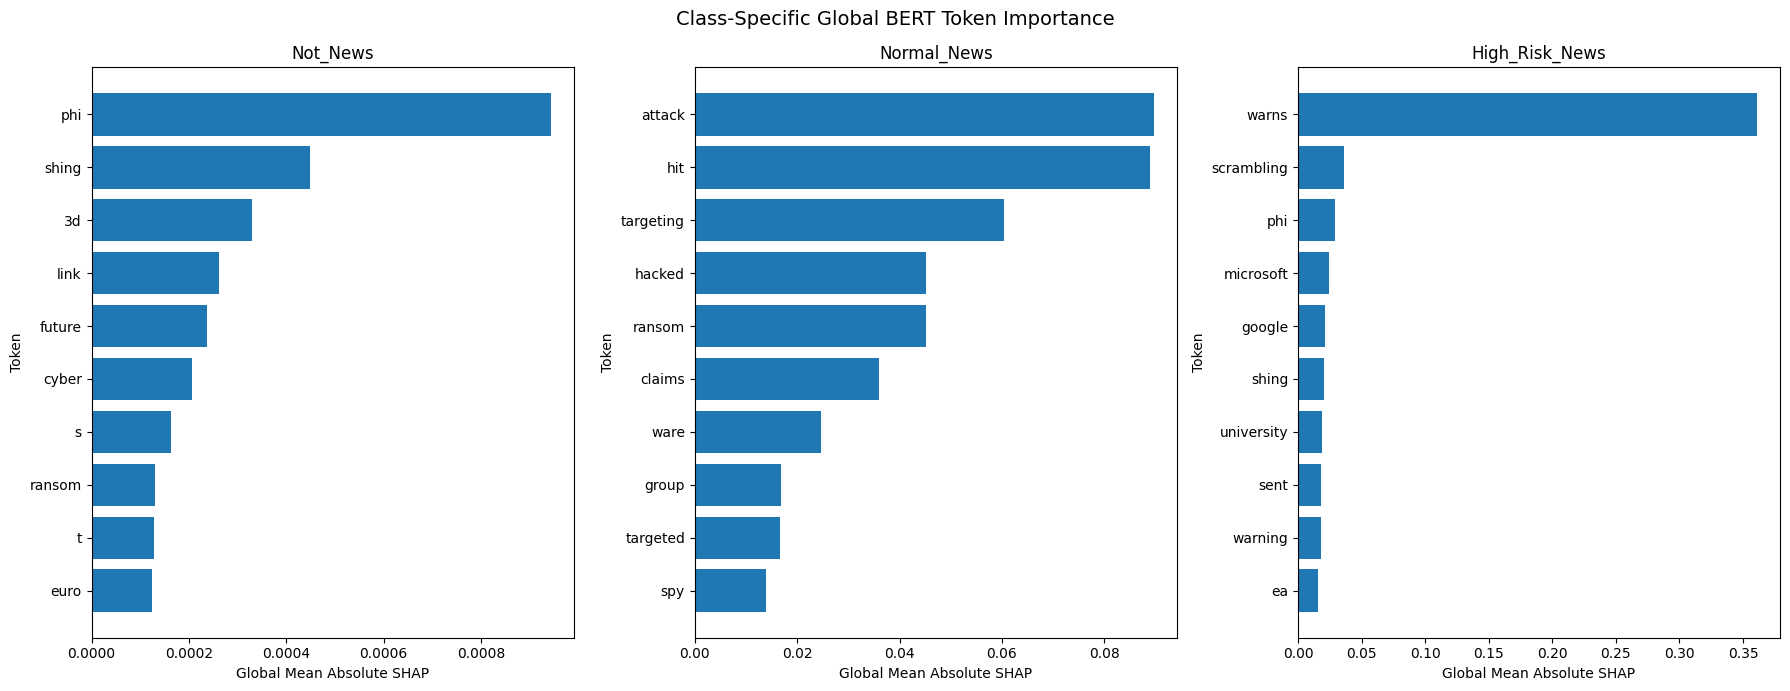

In [61]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 7)
)

plot_data = [
    (
        not_news_semantic_shap.head(10),
        'Not_News'
    ),
    (
        normal_news_semantic_shap.head(10),
        'Normal_News'
    ),
    (
        high_risk_semantic_shap.head(10),
        'High_Risk_News'
    )
]

for ax, (data, class_name) in zip(
    axes,
    plot_data
):
    plot_df = data.sort_values(
        'global_mean_abs_shap',
        ascending=True
    )

    ax.barh(
        plot_df['token'],
        plot_df['global_mean_abs_shap']
    )

    ax.set_title(class_name)
    ax.set_xlabel(
        'Global Mean Absolute SHAP'
    )
    ax.set_ylabel('Token')

plt.suptitle(
    'Class-Specific Global BERT Token Importance',
    fontsize=14
)

plt.tight_layout()
plt.show()

## 12. RQ3 - SHAP Faithfulness via AOPC Deletion

RQ3 evaluates whether the tokens identified by SHAP as important genuinely influence the final BERT model's predictions. A faithful explanation should assign high importance to tokens whose removal causes a substantial reduction in the model's confidence for the originally predicted class.

A deletion-based perturbation experiment is therefore performed. For each correctly classified observation in the stratified SHAP sample, tokens are ranked according to their positive SHAP contribution to the predicted class. Increasing proportions of the highest-ranked tokens are then removed from the text, and the resulting change in predicted-class probability is measured.

The Area Over the Perturbation Curve (AOPC) summarises the average reduction in model confidence across deletion levels. Larger AOPC values indicate that removing SHAP-ranked important tokens produces a greater deterioration in prediction confidence and therefore provides stronger evidence that the explanation is faithful to the model's behaviour.

### AOPC Perturbation Configuration

In [62]:
AOPC_DELETION_LEVELS = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50
]

print(
    "AOPC deletion levels:",
    [
        f"{int(level * 100)}%"
        for level in AOPC_DELETION_LEVELS
    ]
)

AOPC deletion levels: ['10%', '20%', '30%', '40%', '50%']


### SHAP-Ranked Token Deletion

In [63]:
def delete_top_shap_tokens(
    explanation,
    class_id,
    deletion_fraction
):
    """
    Delete the most important positively contributing SHAP-ranked
    lexical units for a specified BERT output class.

    Returns both:
    1. the perturbed text
    2. the number of lexical units actually deleted

    Returning the actual deletion count allows the random-control
    condition to remove exactly the same quantity of text.
    """

    tokens = [
        str(token)
        for token in explanation.data
    ]

    shap_values = np.asarray(
        explanation.values[:, class_id],
        dtype=float
    )


    # 1. Reconstruct lexical units from SHAP fragments

    groups = []
    current_positions = []

    for i, token in enumerate(tokens):

        if token.strip() == '':
            continue

        current_positions.append(i)

        # SHAP text segments commonly preserve trailing
        # whitespace at the end of a lexical unit.
        if token[-1:].isspace():
            groups.append(current_positions)
            current_positions = []

    if current_positions:
        groups.append(current_positions)

    if len(groups) == 0:
        return ''.join(tokens).strip(), 0

   
    # 2. Calculate positive SHAP support per lexical unit

    group_scores = []

    for positions in groups:

        score = np.sum([
            max(shap_values[pos], 0.0)
            for pos in positions
        ])

        group_scores.append(score)

    group_scores = np.asarray(
        group_scores,
        dtype=float
    )

    positive_groups = np.where(
        group_scores > 0
    )[0]

    if len(positive_groups) == 0:
        return ''.join(tokens).strip(), 0

    
    # 3. Determine ACTUAL number of units deleted

    requested_delete = max(
        1,
        int(
            np.ceil(
                len(groups)
                * deletion_fraction
            )
        )
    )

    actual_delete = min(
        requested_delete,
        len(positive_groups)
    )

    ranked_groups = positive_groups[
        np.argsort(
            group_scores[positive_groups]
        )[::-1]
    ]

    groups_to_delete = set(
        ranked_groups[:actual_delete]
    )

    positions_to_delete = set()

    for group_id in groups_to_delete:
        positions_to_delete.update(
            groups[group_id]
        )

    
    # 4. Reconstruct perturbed text

    remaining_parts = []

    for i, token in enumerate(tokens):

        if i not in positions_to_delete:
            remaining_parts.append(token)

        else:
            if token[-1:].isspace():
                remaining_parts.append(' ')

    perturbed_text = ''.join(
        remaining_parts
    )

    perturbed_text = ' '.join(
        perturbed_text.split()
    )

    return perturbed_text, actual_delete

In [64]:
def delete_random_tokens(
    explanation,
    n_delete,
    rng
):
    """
    Random-deletion control.

    Deletes exactly `n_delete` lexical units chosen at random
    using the same lexical grouping as the SHAP-guided condition.

    This ensures that SHAP-guided and random perturbations differ
    only in WHICH lexical units are removed, not in how many.
    """

    tokens = [
        str(token)
        for token in explanation.data
    ]

    # Reconstruct lexical units identically to SHAP deletion
    groups = []
    current_positions = []

    for i, token in enumerate(tokens):

        if token.strip() == '':
            continue

        current_positions.append(i)

        if token[-1:].isspace():
            groups.append(current_positions)
            current_positions = []

    if current_positions:
        groups.append(current_positions)

    if len(groups) == 0 or n_delete == 0:
        return ''.join(tokens).strip()

    n_delete = min(
        int(n_delete),
        len(groups)
    )

    chosen_groups = set(
        rng.choice(
            len(groups),
            size=n_delete,
            replace=False
        )
    )

    positions_to_delete = set()

    for group_id in chosen_groups:
        positions_to_delete.update(
            groups[group_id]
        )

    remaining_parts = []

    for i, token in enumerate(tokens):

        if i not in positions_to_delete:
            remaining_parts.append(token)

        else:
            if token[-1:].isspace():
                remaining_parts.append(' ')

    perturbed_text = ''.join(
        remaining_parts
    )

    return ' '.join(
        perturbed_text.split()
    )

### Verify SHAP-Guided Token Deletion

In [65]:
example_explanation = high_risk_shap_values[0]

example_class_id = 2

example_perturbed_text, example_deleted_count = (
    delete_top_shap_tokens(
        example_explanation,
        class_id=example_class_id,
        deletion_fraction=0.20
    )
)

print("Original text:")
print(
    ''.join(
        example_explanation.data
    ).strip()
)

print(
    "\nAfter deleting top 20% "
    "SHAP-ranked positive lexical units:"
)

print(example_perturbed_text)

print(
    f"\nLexical units actually deleted: "
    f"{example_deleted_count}"
)

Original text:
QNAP Devices Targeted in New Wave of DeadBolt Ransomware Attacks HTTPURL

After deleting top 20% SHAP-ranked positive lexical units:
QNAP Devices Targeted in New of Ransomware Attacks

Lexical units actually deleted: 3


### Compute AOPC Faithfulness Scores

In [66]:
def compute_aopc_for_class(
    shap_values,
    texts,
    class_id,
    class_name,
    deletion_levels=AOPC_DELETION_LEVELS
):
    """
    Compute SHAP-guided deletion-based AOPC for one class.

    For each observation and deletion level, the function records
    the number of positively contributing lexical units that were
    actually deleted. This count is later used to construct a
    matched random-deletion control.
    """

    records = []

    for i, explanation in enumerate(shap_values):

        original_text = texts[i]

        original_prob = bert_predict_proba(
            [original_text]
        )[0, class_id]

        for deletion_fraction in deletion_levels:

            (
                perturbed_text,
                actual_deleted_count
            ) = delete_top_shap_tokens(
                explanation,
                class_id=class_id,
                deletion_fraction=deletion_fraction
            )

            perturbed_prob = bert_predict_proba(
                [perturbed_text]
            )[0, class_id]

            probability_drop = (
                original_prob
                - perturbed_prob
            )

            records.append({
                'class_name': class_name,
                'observation_id': i,
                'deletion_fraction':
                    deletion_fraction,
                'actual_deleted_count':
                    actual_deleted_count,
                'original_probability':
                    original_prob,
                'perturbed_probability':
                    perturbed_prob,
                'probability_drop':
                    probability_drop
            })

    return pd.DataFrame(records)

In [67]:
def compute_random_aopc_for_class(
    shap_values,
    texts,
    class_id,
    class_name,
    shap_aopc_results,
    n_repeats=20,
    base_seed=SEED
):
    """
    Matched random-deletion baseline for the SHAP AOPC experiment.

    For every observation and deletion level, random deletion
    removes exactly the same number of lexical units that the
    corresponding SHAP-guided perturbation actually removed.

    Multiple random draws are averaged to reduce sampling noise.
    """

    records = []

    class_shap_results = (
        shap_aopc_results[
            shap_aopc_results[
                'class_name'
            ] == class_name
        ]
        .copy()
    )

    for i, explanation in enumerate(shap_values):

        original_text = texts[i]

        original_prob = bert_predict_proba(
            [original_text]
        )[0, class_id]

        observation_results = (
            class_shap_results[
                class_shap_results[
                    'observation_id'
                ] == i
            ]
        )

        for _, shap_row in observation_results.iterrows():

            deletion_fraction = float(
                shap_row['deletion_fraction']
            )

            n_delete = int(
                shap_row['actual_deleted_count']
            )

            drops = []

            for r in range(n_repeats):

                rng = np.random.default_rng(
                    base_seed
                    + (10000 * class_id)
                    + (100 * i)
                    + r
                )

                perturbed_text = delete_random_tokens(
                    explanation,
                    n_delete=n_delete,
                    rng=rng
                )

                perturbed_prob = bert_predict_proba(
                    [perturbed_text]
                )[0, class_id]

                drops.append(
                    original_prob
                    - perturbed_prob
                )

            records.append({
                'class_name':
                    class_name,

                'observation_id':
                    i,

                'deletion_fraction':
                    deletion_fraction,

                'actual_deleted_count':
                    n_delete,

                'original_probability':
                    original_prob,

                'mean_random_probability_drop':
                    float(np.mean(drops)),

                'std_random_probability_drop':
                    float(np.std(
                        drops,
                        ddof=1
                    )) if len(drops) > 1 else 0.0
            })

    return pd.DataFrame(records)

In [68]:
not_news_aopc = compute_aopc_for_class(
    not_news_shap_values,
    not_news_shap_texts,
    class_id=0,
    class_name='Not_News'
)

normal_news_aopc = compute_aopc_for_class(
    normal_news_shap_values,
    normal_news_shap_texts,
    class_id=1,
    class_name='Normal_News'
)

high_risk_aopc = compute_aopc_for_class(
    high_risk_shap_values,
    high_risk_shap_texts,
    class_id=2,
    class_name='High_Risk_News'
)

aopc_results = pd.concat(
    [
        not_news_aopc,
        normal_news_aopc,
        high_risk_aopc
    ],
    ignore_index=True
)

print("AOPC deletion experiment completed.")
print(f"Total perturbation evaluations: {len(aopc_results):,}")

AOPC deletion experiment completed.
Total perturbation evaluations: 750


In [69]:
# Audit how many lexical units SHAP actually removes
# at each deletion level for each class.

deletion_count_audit = (
    aopc_results
    .groupby([
        'class_name',
        'deletion_fraction'
    ])
    .agg(
        mean_units_deleted=(
            'actual_deleted_count',
            'mean'
        ),
        median_units_deleted=(
            'actual_deleted_count',
            'median'
        ),
        min_units_deleted=(
            'actual_deleted_count',
            'min'
        ),
        max_units_deleted=(
            'actual_deleted_count',
            'max'
        )
    )
    .reset_index()
)

display(
    deletion_count_audit.style.format({
        'deletion_fraction': '{:.0%}',
        'mean_units_deleted': '{:.2f}',
        'median_units_deleted': '{:.1f}'
    })
)

,class_name,deletion_fraction,mean_units_deleted,median_units_deleted,min_units_deleted,max_units_deleted
0,High_Risk_News,10%,2.28,2.0,1,5
1,High_Risk_News,20%,3.86,3.0,2,10
2,High_Risk_News,30%,5.56,4.0,3,15
3,High_Risk_News,40%,7.26,6.0,4,19
4,High_Risk_News,50%,8.84,7.0,4,24
5,Normal_News,10%,2.32,2.0,1,5
6,Normal_News,20%,4.06,3.0,2,9
7,Normal_News,30%,5.88,5.0,3,14
8,Normal_News,40%,7.78,6.0,4,18
9,Normal_News,50%,9.46,8.0,4,22


In [70]:
# Matched random-deletion control:
# same observations and EXACTLY the same number of deleted
# lexical units as the corresponding SHAP perturbation.

not_news_random = compute_random_aopc_for_class(
    not_news_shap_values,
    not_news_shap_texts,
    class_id=0,
    class_name='Not_News',
    shap_aopc_results=aopc_results
)

normal_news_random = compute_random_aopc_for_class(
    normal_news_shap_values,
    normal_news_shap_texts,
    class_id=1,
    class_name='Normal_News',
    shap_aopc_results=aopc_results
)

high_risk_random = compute_random_aopc_for_class(
    high_risk_shap_values,
    high_risk_shap_texts,
    class_id=2,
    class_name='High_Risk_News',
    shap_aopc_results=aopc_results
)

random_aopc_results = pd.concat(
    [
        not_news_random,
        normal_news_random,
        high_risk_random
    ],
    ignore_index=True
)


# Observation-level AOPC

shap_observation_aopc = (
    aopc_results
    .groupby([
        'class_name',
        'observation_id'
    ])['probability_drop']
    .mean()
    .reset_index(
        name='SHAP_AOPC'
    )
)

random_observation_aopc = (
    random_aopc_results
    .groupby([
        'class_name',
        'observation_id'
    ])['mean_random_probability_drop']
    .mean()
    .reset_index(
        name='Random_AOPC'
    )
)

paired_aopc = pd.merge(
    shap_observation_aopc,
    random_observation_aopc,
    on=[
        'class_name',
        'observation_id'
    ],
    how='inner'
)

paired_aopc['SHAP_minus_random'] = (
    paired_aopc['SHAP_AOPC']
    - paired_aopc['Random_AOPC']
)

faithfulness_comparison = (
    paired_aopc
    .groupby('class_name')
    .agg(
        SHAP_guided_AOPC=(
            'SHAP_AOPC',
            'mean'
        ),
        Random_AOPC=(
            'Random_AOPC',
            'mean'
        ),
        SHAP_minus_random=(
            'SHAP_minus_random',
            'mean'
        )
    )
    .reindex(CLASS_NAMES)
    .reset_index()
)

display(
    faithfulness_comparison.style.format({
        'SHAP_guided_AOPC': '{:.4f}',
        'Random_AOPC': '{:.4f}',
        'SHAP_minus_random': '{:.4f}'
    })
)

,class_name,SHAP_guided_AOPC,Random_AOPC,SHAP_minus_random
0,Not_News,-0.0001,0.0004,-0.0004
1,Normal_News,0.8257,0.2853,0.5403
2,High_Risk_News,0.8886,0.3675,0.5210


In [71]:
aopc_by_level = (
    aopc_results
    .groupby([
        'class_name',
        'deletion_fraction'
    ])
    .agg(
        mean_probability_drop=('probability_drop', 'mean'),
        median_probability_drop=('probability_drop', 'median'),
        mean_perturbed_probability=('perturbed_probability', 'mean')
    )
    .reset_index()
)

display(
    aopc_by_level.style.format({
        'deletion_fraction': '{:.0%}',
        'mean_probability_drop': '{:.4f}',
        'median_probability_drop': '{:.4f}',
        'mean_perturbed_probability': '{:.4f}'
    })
)

,class_name,deletion_fraction,mean_probability_drop,median_probability_drop,mean_perturbed_probability
0,High_Risk_News,10%,0.7781,0.9858,0.1927
1,High_Risk_News,20%,0.8400,0.9900,0.1308
2,High_Risk_News,30%,0.9114,0.9962,0.0594
3,High_Risk_News,40%,0.9429,0.9965,0.0278
4,High_Risk_News,50%,0.9704,0.9966,0.0004
5,Normal_News,10%,0.5182,0.7222,0.4755
6,Normal_News,20%,0.7495,0.9883,0.2442
7,Normal_News,30%,0.9074,0.9939,0.0864
8,Normal_News,40%,0.9831,0.9949,0.0107
9,Normal_News,50%,0.9702,0.9952,0.0236


In [72]:
class_aopc_summary = (
    aopc_results
    .groupby([
        'class_name',
        'observation_id'
    ])['probability_drop']
    .mean()
    .reset_index(
        name='observation_aopc'
    )
    .groupby('class_name')
    .agg(
        mean_AOPC=('observation_aopc', 'mean'),
        median_AOPC=('observation_aopc', 'median'),
        std_AOPC=('observation_aopc', 'std')
    )
    .reset_index()
)

display(
    class_aopc_summary.style.format({
        'mean_AOPC': '{:.4f}',
        'median_AOPC': '{:.4f}',
        'std_AOPC': '{:.4f}'
    })
)

,class_name,mean_AOPC,median_AOPC,std_AOPC
0,High_Risk_News,0.8886,0.9891,0.1413
1,Normal_News,0.8257,0.9330,0.2046
2,Not_News,-0.0001,0.0000,0.0016


### RQ3 Interpretation - Faithfulness of SHAP Explanations

RQ3 asks whether the SHAP explanations faithfully reflect the decision behaviour of the BERT cybersecurity classifier. Faithfulness was evaluated using an AOPC-style deletion experiment in which positively contributing SHAP-ranked lexical units were progressively removed and the resulting decrease in the model's predicted probability for the original class was measured.

To provide a stronger control, the SHAP-guided perturbations were compared with matched random deletion. For every observation and deletion level, the random baseline removed exactly the same number of lexical units as the corresponding SHAP-guided perturbation. Random deletion was repeated multiple times and averaged to reduce sampling variability.

The results show clear evidence of explanation faithfulness for the `High_Risk_News` and `Normal_News` classes. For `High_Risk_News`, SHAP-guided deletion produced a mean AOPC of **0.8886**, compared with **0.3675** for matched random deletion, giving a mean advantage of **0.5210**. Similarly, for `Normal_News`, SHAP-guided deletion achieved a mean AOPC of **0.8257**, compared with **0.2853** for random deletion, producing a difference of **0.5403**.

The deletion curves also show a progressive reduction in model confidence as increasingly large proportions of SHAP-ranked evidence are removed. For `High_Risk_News`, the mean probability drop increases from **0.7781 at 10% deletion** to **0.9704 at 50% deletion**. For `Normal_News`, the corresponding probability drop increases from **0.5182 at 10% deletion** to approximately **0.97 at 50% deletion**. This indicates that the lexical evidence identified by SHAP is substantially more influential on the model's predictions than equally sized randomly selected evidence.

In contrast, `Not_News` produces a mean SHAP-guided AOPC of approximately **-0.0001**, while matched random deletion produces approximately **0.0004**. The difference is therefore negligible. Under the implemented positive-support deletion protocol, this experiment does **not provide convincing evidence of SHAP faithfulness for the `Not_News` class**.

One plausible explanation is that `Not_News` decisions may depend less on a small set of strongly positive lexical cues and more on the absence of cybersecurity-related evidence or on distributed contextual information. However, this interpretation cannot be established from the current deletion experiment alone and should therefore be treated as a hypothesis rather than a demonstrated finding.

Overall, RQ3 is answered with class-dependent evidence. SHAP explanations are strongly supported as faithful for `High_Risk_News` and `Normal_News`, because deleting SHAP-ranked evidence causes substantially larger confidence reductions than matched random deletion. Faithfulness for `Not_News`, however, remains inconclusive under the current positive-evidence deletion metric.

### SHAP Faithfulness Across Deletion Levels

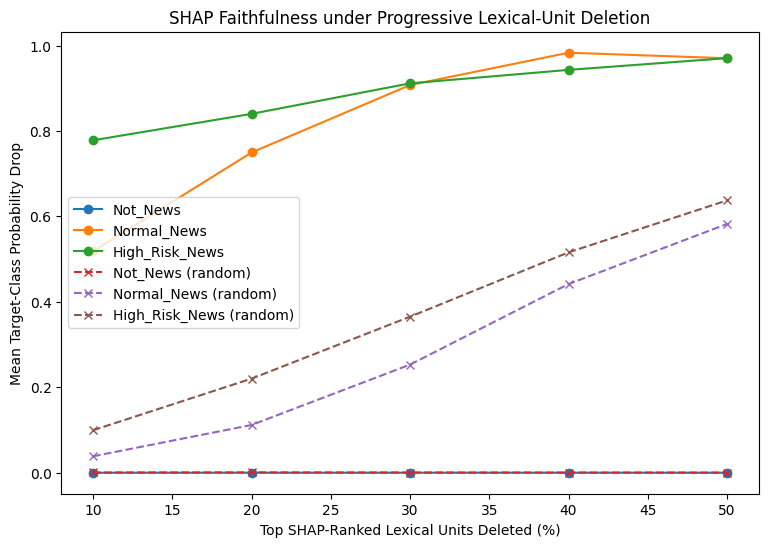

In [73]:
plt.figure(figsize=(9, 6))

# SHAP-guided deletion curves
for class_name in CLASS_NAMES:

    class_results = aopc_by_level[
        aopc_by_level['class_name'] == class_name
    ]

    plt.plot(
        class_results['deletion_fraction'] * 100,
        class_results['mean_probability_drop'],
        marker='o',
        label=class_name
    )

# Matched random-deletion control
random_by_level = (
    random_aopc_results
    .groupby(
        ['class_name', 'deletion_fraction']
    )['mean_random_probability_drop']
    .mean()
    .reset_index()
)

for class_name in CLASS_NAMES:

    cr = random_by_level[
        random_by_level['class_name'] == class_name
    ]

    plt.plot(
        cr['deletion_fraction'] * 100,
        cr['mean_random_probability_drop'],
        marker='x',
        linestyle='--',
        label=f'{class_name} (random)'
    )

plt.xlabel('Top SHAP-Ranked Lexical Units Deleted (%)')
plt.ylabel('Mean Target-Class Probability Drop')
plt.title(
    'SHAP Faithfulness under Progressive Lexical-Unit Deletion'
)
plt.legend()
plt.show()

## 13. RQ4 - Cross-Model Lexical Agreement

RQ4 investigates the extent to which the TF-IDF + Logistic Regression baseline and the fine-tuned BERT model rely on similar lexical evidence when assigning cybersecurity classes.

The Logistic Regression model provides directly interpretable class-specific coefficient rankings, whereas BERT is interpreted using the aggregated class-specific SHAP rankings produced in RQ2. Because the two models operate on fundamentally different representations, direct comparison of coefficient magnitudes with SHAP magnitudes would not be meaningful.

Instead, the analysis compares highly ranked lexical cues after applying a common normalisation procedure. Logistic Regression is restricted to unigram features, while BERT SHAP text segments are normalised into comparable lexical forms before overlap is calculated.

Agreement is evaluated at Top-10 and Top-20 ranking depths rather than relying on a single arbitrary threshold. A Top-50 comparison is not reported because fewer than 50 eligible Logistic Regression unigram features remain for some classes after lexical filtering, which would make a fixed Top-50 percentage comparison inconsistent. For each valid ranking depth, both percentage overlap and Jaccard similarity are reported.

Higher overlap indicates that both models emphasise similar lexical cues, whereas lower overlap suggests that comparable predictions may be supported by different lexical evidence.

### Load Logistic Regression Coefficient Rankings

In [74]:
baseline_coefficient_files = glob.glob(
    '/kaggle/input/**/baseline_coefficient_rankings.csv',
    recursive=True
)

if len(baseline_coefficient_files) == 0:
    raise FileNotFoundError(
        "baseline_coefficient_rankings.csv could not be found."
    )

baseline_coefficients_path = baseline_coefficient_files[0]

lr_coefficients = pd.read_csv(
    baseline_coefficients_path
)

print("Coefficient rankings loaded from:")
print(baseline_coefficients_path)

print("\nColumns:")
print(lr_coefficients.columns.tolist())

display(
    lr_coefficients.head(10)
)

Coefficient rankings loaded from:
/kaggle/input/notebooks/vidhi0405/cybattt-baseline-tfidf-lr-fyp/baseline_coefficient_rankings.csv

Columns:
['Class', 'Rank', 'Feature', 'Coefficient', 'Document frequency']


,Class,Rank,Feature,Coefficient,Document frequency
0,Not_News,1,learn,7.383070,885
1,Not_News,2,worms,7.087279,711
2,Not_News,3,protect,7.065747,746
3,Not_News,4,like,7.052184,1022
4,Not_News,5,know,6.784725,759
5,Not_News,6,get,6.456408,1011
6,Not_News,7,ransomware,6.132414,15964
7,Not_News,8,need,6.043090,700
8,Not_News,9,honeypot,6.005436,504
9,Not_News,10,phishing,5.985927,7169


### Lexically Comparable Cross-Model Analysis

Because the Logistic Regression representation contains unigrams, bigrams and trigrams whereas BERT SHAP explanations operate at token/subword level, direct comparison of all ranked features could underestimate lexical agreement. The final comparison therefore restricts the Logistic Regression rankings to unigram features and applies the same interpretation-focused filtering used for BERT SHAP.

This produces a more comparable lexical analysis while preserving the original model-specific rankings.

In [75]:
# Prepare comparable LR unigram rankings

lr_unigrams = lr_coefficients[
    ~lr_coefficients['Feature'].astype(str).str.contains(
        r'\s',
        regex=True
    )
].copy()

lr_unigrams['normalised_feature'] = (
    lr_unigrams['Feature']
    .astype(str)
    .str.strip()
    .str.lower()
)

# Apply the same display exclusions used for BERT
lr_unigrams = lr_unigrams[
    ~lr_unigrams['normalised_feature'].isin(
        SHAP_DISPLAY_EXCLUDE
    )
].copy()

print(
    f"LR unigram coefficient rows available: "
    f"{len(lr_unigrams):,}"
)

LR unigram coefficient rows available: 97


In [76]:
import re

def normalise_rq4_term(term):
    """
    Normalise LR and BERT terms into comparable lexical forms.
    """

    term = str(term).strip().lower()

    # Remove WordPiece continuation marker if present
    term = term.replace('##', '')

    # Extract lexical content
    match = re.search(
        r"[a-z0-9]+(?:['-][a-z0-9]+)*",
        term
    )

    if match is None:
        return ''

    return match.group(0)


# Normalise the existing interpretation-focused exclusions
# so that the same filtering logic is applied to BERT terms.
rq4_exclude_terms = {
    normalise_rq4_term(term)
    for term in SHAP_DISPLAY_EXCLUDE
}

rq4_exclude_terms.discard('')


def prepare_bert_rq4_rankings(
    global_shap_table,
    top_n=200
):
    """
    Prepare unique, filtered and normalised
    BERT SHAP lexical rankings for RQ4.
    """

    ranked = (
        global_shap_table
        .sort_values(
            'global_mean_abs_shap',
            ascending=False
        )
        .copy()
    )

    ranked['normalised_term'] = (
        ranked['token']
        .apply(normalise_rq4_term)
    )

    # Remove empty lexical items
    ranked = ranked[
        ranked['normalised_term'] != ''
    ].copy()

    # Apply the same interpretation-focused exclusions
    # used in the LR comparison.
    ranked = ranked[
        ~ranked['normalised_term'].isin(
            rq4_exclude_terms
        )
    ].copy()

    # Retain lexical items containing alphabetic content
    ranked = ranked[
        ranked['normalised_term']
        .str.contains(
            r'[a-zA-Z]',
            regex=True
        )
    ].copy()

    # Keep the highest-ranked occurrence of each
    # normalised lexical term.
    ranked = (
        ranked
        .drop_duplicates(
            subset='normalised_term',
            keep='first'
        )
        .head(top_n)
        .reset_index(drop=True)
    )

    ranked['lexical_rank'] = (
        np.arange(len(ranked)) + 1
    )

    return ranked


not_news_rq4_shap = prepare_bert_rq4_rankings(
    not_news_global_shap
)

normal_news_rq4_shap = prepare_bert_rq4_rankings(
    normal_news_global_shap
)

high_risk_rq4_shap = prepare_bert_rq4_rankings(
    high_risk_global_shap
)

bert_rq4_by_class = {
    'Not_News': not_news_rq4_shap,
    'Normal_News': normal_news_rq4_shap,
    'High_Risk_News': high_risk_rq4_shap
}

print("BERT SHAP rankings prepared for RQ4.")

for class_name in CLASS_NAMES:
    print(
        class_name,
        bert_rq4_by_class[class_name].columns.tolist()
    )

BERT SHAP rankings prepared for RQ4.
Not_News ['token', 'total_shap', 'total_abs_shap', 'document_frequency', 'mean_shap_per_document', 'global_mean_abs_shap', 'document_frequency_pct', 'class_name', 'normalised_term', 'lexical_rank']
Normal_News ['token', 'total_shap', 'total_abs_shap', 'document_frequency', 'mean_shap_per_document', 'global_mean_abs_shap', 'document_frequency_pct', 'class_name', 'normalised_term', 'lexical_rank']
High_Risk_News ['token', 'total_shap', 'total_abs_shap', 'document_frequency', 'mean_shap_per_document', 'global_mean_abs_shap', 'document_frequency_pct', 'class_name', 'normalised_term', 'lexical_rank']


In [77]:
RQ4_TOP_K_VALUES = [10, 20]

rq4_records = []
rq4_shared_terms = {}

for class_name in CLASS_NAMES:

    # Logistic Regression ranked unigrams
    lr_class = (
        lr_unigrams[
            lr_unigrams['Class'] == class_name
        ]
        .sort_values('Rank')
    )

    lr_terms_ordered = []

    for term in lr_class['normalised_feature']:

        term = normalise_rq4_term(term)

        if (
            term != ''
            and term not in lr_terms_ordered
        ):
            lr_terms_ordered.append(term)

    # BERT ranked SHAP lexical terms
    bert_class = (
        bert_rq4_by_class[class_name]
        .sort_values('lexical_rank')
    )

    bert_terms_ordered = (
        bert_class['normalised_term']
        .tolist()
    )

    # Compare Top-10 and Top-20
    for top_k in RQ4_TOP_K_VALUES:

        lr_top = set(
            lr_terms_ordered[:top_k]
        )

        bert_top = set(
            bert_terms_ordered[:top_k]
        )

        shared = lr_top & bert_top
        union = lr_top | bert_top

        overlap_count = len(shared)

        overlap_percentage = (
            overlap_count / top_k * 100
        )

        jaccard_similarity = (
            overlap_count / len(union)
            if len(union) > 0
            else 0.0
        )

        rq4_shared_terms[
            (class_name, top_k)
        ] = sorted(shared)

        rq4_records.append({
            'Class': class_name,
            'Top_k': top_k,
            'LR features': len(lr_top),
            'BERT features': len(bert_top),
            'Shared features': overlap_count,
            'Overlap (%)': overlap_percentage,
            'Jaccard similarity': jaccard_similarity
        })

rq4_overlap_summary = pd.DataFrame(
    rq4_records
)

display(
    rq4_overlap_summary.style.format({
        'Overlap (%)': '{:.1f}%',
        'Jaccard similarity': '{:.4f}'
    })
)

,Class,Top_k,LR features,BERT features,Shared features,Overlap (%),Jaccard similarity
0,Not_News,10,10,10,0,0.0%,0.0000
1,Not_News,20,20,20,1,5.0%,0.0256
2,Normal_News,10,10,10,6,60.0%,0.4286
3,Normal_News,20,20,20,9,45.0%,0.2903
4,High_Risk_News,10,10,10,2,20.0%,0.1111
5,High_Risk_News,20,20,20,4,20.0%,0.1111


In [78]:
for class_name in CLASS_NAMES:

    print(f"\n{class_name}")
    print("=" * 50)

    for top_k in RQ4_TOP_K_VALUES:

        shared = rq4_shared_terms[
            (class_name, top_k)
        ]

        print(
            f"\nTop-{top_k} shared lexical features "
            f"({len(shared)}):"
        )

        if shared:
            print(", ".join(shared))
        else:
            print(
                "No shared top-ranked lexical features."
            )


Not_News

Top-10 shared lexical features (0):
No shared top-ranked lexical features.

Top-20 shared lexical features (1):
like

Normal_News

Top-10 shared lexical features (6):
claims, group, hacked, hit, targeted, targeting

Top-20 shared lexical features (9):
attacked, claims, group, hacked, hit, target, targeted, targeting, targets

High_Risk_News

Top-10 shared lexical features (2):
warning, warns

Top-20 shared lexical features (4):
north, users, warning, warns


### RQ4 Interpretation - Cross-Model Lexical Agreement

RQ4 examines the extent to which the TF-IDF + Logistic Regression baseline and the fine-tuned BERT model emphasise similar lexical cues when making class predictions.

To reduce representation mismatch, Logistic Regression was restricted to unigram features and BERT SHAP text segments were normalised into comparable lexical forms. Agreement was evaluated at two ranking depths (Top-10 and Top-20) using percentage overlap and Jaccard similarity. A Top-50 comparison was not reported because fewer than 50 eligible Logistic Regression unigram features were available for some classes after lexical filtering, meaning that a fixed Top-50 comparison would not be methodologically consistent across all classes.

The results show that cross-model lexical agreement differs substantially by class.

For `Normal_News`, agreement is consistently the strongest. Six of the Top-10 lexical cues are shared between the two models, corresponding to **60.0% overlap** and a Jaccard similarity of **0.4286**. At Top-20, nine features are shared, corresponding to **45.0% overlap** and a Jaccard similarity of **0.2903**. Shared terms include `claims`, `group`, `hacked`, `hit`, `targeted` and `targeting`. This indicates that both models place substantial importance on a common set of explicit incident-related lexical cues when identifying `Normal_News`.

Agreement is lower for `High_Risk_News`. Two Top-10 terms are shared (`warning` and `warns`), corresponding to **20.0% overlap** and a Jaccard similarity of **0.1111**. At Top-20, four features are shared (`north`, `users`, `warning` and `warns`), again corresponding to **20.0% overlap** and a Jaccard similarity of **0.1111**. The repeated presence of warning-related terms suggests that both models identify a small common core of lexical evidence associated with high-risk cybersecurity communication, while differing substantially in the remainder of their highly ranked features.

For `Not_News`, agreement is the weakest. No lexical features are shared within the Top-10 rankings, corresponding to **0.0% overlap** and a Jaccard similarity of **0.0000**. At Top-20, only one feature (`like`) is shared, corresponding to **5.0% overlap** and a Jaccard similarity of **0.0256**. This indicates that the two models place substantially different emphasis on lexical features when identifying the majority `Not_News` class.

Overall, the analysis shows a clear class-dependent pattern of cross-model lexical agreement. `Normal_News` demonstrates the highest agreement, with **60.0% Top-10 overlap** and **45.0% Top-20 overlap**. `High_Risk_News` shows more limited agreement, with **20.0% overlap** at both ranking depths, while `Not_News` exhibits minimal agreement, with **0.0% Top-10 overlap** and only **5.0% Top-20 overlap**.

These findings suggest that the models converge most strongly on lexical cues associated with general cybersecurity incidents, whereas their representations of high-risk and non-news content differ more substantially. However, the comparison should be interpreted as **global lexical-feature agreement rather than equivalence of the models' internal reasoning**. Logistic Regression coefficients represent fixed global linear feature weights, whereas BERT SHAP values represent contextual contribution estimates aggregated across sampled observations. Consequently, the overlap analysis identifies common highly ranked lexical cues but does not imply that both models use those cues in the same way internally.

## 14. Local SHAP Case Studies

Global SHAP summaries describe broad class-level patterns, but they do not show how the model arrives at individual predictions. A small set of local case studies is therefore examined to illustrate how token-level SHAP attributions operate at the observation level.

The case studies include correctly classified examples from each class together with selected misclassified observations. These examples are used descriptively to demonstrate how supportive and opposing textual evidence contributes to individual BERT predictions.

In [79]:
# Select one correctly classified example from each class

local_correct_cases = []

for class_id in [0, 1, 2]:

    candidates = shap_sampling_frame[
        (shap_sampling_frame['true_label'] == class_id)
        &
        (shap_sampling_frame['predicted_label'] == class_id)
    ]

    selected = candidates.sample(
        n=1,
        random_state=SEED
    )

    local_correct_cases.append(selected)

local_correct_cases = pd.concat(
    local_correct_cases,
    ignore_index=True
)

local_correct_cases['text'] = (
    local_correct_cases['row_id']
    .map(df['bert_text'])
)

display(
    local_correct_cases[
        [
            'row_id',
            'class_name',
            'text'
        ]
    ]
)

,row_id,class_name,text
0,4672,Not_News,"In independent tests, Forcepoint Zero Trust CD..."
1,34693,Normal_News,#Walmart denies being hit by #Yanluowang #rans...
2,35058,High_Risk_News,QNAP Devices Targeted in New Wave of DeadBolt ...


### Generate Local SHAP Explanations for Correctly Classified Cases

In [80]:
correct_case_texts = (
    local_correct_cases['text']
    .tolist()
)

correct_case_shap = shap_explainer(
    correct_case_texts,
    max_evals=500
)

print("Local SHAP explanations generated.")
print("Number of explained cases:", len(correct_case_shap))

Local SHAP explanations generated.
Number of explained cases: 3


### Display Correct-Case SHAP Explanations

In [81]:
for i, row in local_correct_cases.iterrows():

    true_class = row['class_name']
    true_class_id = int(row['true_label'])

    print("=" * 80)
    print(f"Case {i + 1}")
    print(f"Row ID: {row['row_id']}")
    print(f"True / Predicted class: {true_class}")
    print("=" * 80)

    shap.plots.text(
        correct_case_shap[i, :, true_class_id]
    )

Case 1
Row ID: 4672
True / Predicted class: Not_News


Case 2
Row ID: 34693
True / Predicted class: Normal_News


Case 3
Row ID: 35058
True / Predicted class: High_Risk_News


### Interpretation of Correctly Classified Local Cases

The local SHAP explanations are consistent with the global class-level findings.

For the `Not_News` example, token contributions are very small and distributed across the sequence, supporting the earlier observation that this class does not rely on a small number of dominant lexical cues.

For the `Normal_News` example, incident-reporting terms such as `hit`, `denies`, and `attack` make strong positive contributions to the prediction, reflecting the lexical pattern observed in the global SHAP analysis.

For the `High_Risk_News` example, terms associated with an active and potentially serious cyber threat, including `Targeted`, `Wave`, `DeadBolt`, `Ransomware`, and `Attacks`, contribute positively to the model output. This illustrates how BERT combines multiple contextual threat-related cues when assigning the high-risk class.

### Misclassified Local Case Studies

In [82]:
# Select representative BERT misclassifications systematically

error_case_candidates = []

# Case 1: High_Risk_News incorrectly predicted as Normal_News
case_1 = bert_errors[
    (bert_errors['true_class'] == 'High_Risk_News')
    & (bert_errors['predicted_class'] == 'Normal_News')
]

if len(case_1) > 0:
    error_case_candidates.append(
        case_1.iloc[0]
    )


# Case 2: Normal_News incorrectly predicted as Not_News
case_2 = bert_errors[
    (bert_errors['true_class'] == 'Normal_News')
    & (bert_errors['predicted_class'] == 'Not_News')
]

if len(case_2) > 0:
    error_case_candidates.append(
        case_2.iloc[0]
    )


# Case 3: Not_News incorrectly predicted as Normal_News
case_3 = bert_errors[
    (bert_errors['true_class'] == 'Not_News')
    & (bert_errors['predicted_class'] == 'Normal_News')
]

if len(case_3) > 0:
    error_case_candidates.append(
        case_3.iloc[0]
    )


local_error_cases = (
    pd.DataFrame(error_case_candidates)
    .reset_index(drop=True)
)

# Use the exact BERT-prepared input that produced
# the held-out test prediction

local_error_cases['text'] = (
    local_error_cases['row_id']
    .map(df['bert_text'])
)

display(
    local_error_cases[
        [
            'row_id',
            'true_class',
            'predicted_class',
            'text'
        ]
    ]
)

,row_id,true_class,predicted_class,text
0,35937,High_Risk_News,Normal_News,It was reported on Saturday 2 July that a Dutc...
1,31461,Normal_News,Not_News,FROM THE NEWSROOM: (PLAINFIELD) Plainfield Pol...
2,24006,Not_News,Normal_News,"""FBI confirms it obtained NSO's Pegasus spywar..."


In [83]:
# Prepare the systematically selected error cases for local SHAP analysis

error_case_texts = (
    local_error_cases['text']
    .tolist()
)

error_case_true_labels = (
    local_error_cases['true_class']
    .tolist()
)

error_case_predicted_labels = (
    local_error_cases['predicted_class']
    .tolist()
)

print(
    f"Number of selected error cases: "
    f"{len(error_case_texts)}"
)

for i, row in local_error_cases.iterrows():

    print(
        f"\nCase {i + 1}: "
        f"{row['true_class']} → "
        f"{row['predicted_class']}"
    )

    print(row['text'])

Number of selected error cases: 3

Case 1: High_Risk_News → Normal_News
It was reported on Saturday 2 July that a Dutch university that fell victim to a massive ransomware attack has received back part of its stolen money, which in the meantime more than doubled in value, reports Al Arabiya. #HigherEd #Research #Teaching

Case 2: Normal_News → Not_News
FROM THE NEWSROOM: (PLAINFIELD) Plainfield Police say that Town and Police Department leadership are working to resolve a ransomware attack that is affecting the Police Department and the Town Hall. HTTPURL

Case 3: Not_News → Normal_News
"FBI confirms it obtained NSO's Pegasus spyware. HTTPURL


### Generate SHAP Explanations for Misclassified Cases

In [84]:
error_case_texts = (
    local_error_cases['text']
    .tolist()
)

error_case_shap = shap_explainer(
    error_case_texts,
    max_evals=500
)

print("Misclassified-case SHAP explanations generated.")
print("Number of explained cases:", len(error_case_shap))

Misclassified-case SHAP explanations generated.
Number of explained cases: 3


### Display Misclassified-Case SHAP Explanations

In [85]:
for i, row in local_error_cases.iterrows():

    true_class = row['true_class']
    predicted_class = row['predicted_class']

    predicted_class_id = LABEL_MAP[
        predicted_class
    ]

    print("=" * 80)
    print(f"Error Case {i + 1}")
    print(f"Row ID: {row['row_id']}")
    print(f"True class: {true_class}")
    print(f"Predicted class: {predicted_class}")
    print("=" * 80)

    shap.plots.text(
        error_case_shap[
            i,
            :,
            predicted_class_id
        ]
    )

Error Case 1
Row ID: 35937
True class: High_Risk_News
Predicted class: Normal_News


Error Case 2
Row ID: 31461
True class: Normal_News
Predicted class: Not_News


Error Case 3
Row ID: 24006
True class: Not_News
Predicted class: Normal_News


### Interpretation of Misclassified SHAP Cases

The three selected misclassifications illustrate distinct failure modes in the final BERT classifier.

**Case 1: `High_Risk_News → Normal_News`**

The tweet describes a ransomware incident affecting a Dutch university and includes clearly threat-related terms such as `victim`, `attack`, `ransomware` and `stolen`. However, the model assigns a high probability to `Normal_News`. The SHAP explanation shows that terms such as `reported`, `victim`, `Dutch`, `university` and `attack` contribute positively toward the predicted `Normal_News` class. This suggests that the model recognises the tweet as cybersecurity-related but interprets it primarily as reporting about an incident rather than as sufficiently high-risk threat intelligence.

**Case 2: `Normal_News → Not_News`**

This tweet explicitly describes a ransomware attack affecting a police department and town hall, yet the model predicts `Not_News` with very high confidence. The SHAP explanation shows only weak positive support for the predicted class, while threat-related fragments such as `attack` and `ransomware` contribute negatively toward `Not_News`. This indicates a difficult boundary case in which the model fails to convert clearly cyber-related lexical evidence into the correct `Normal_News` classification.

**Case 3: `Not_News → Normal_News`**

The tweet states that the FBI obtained NSO's Pegasus spyware. The SHAP explanation shows strong positive contribution from terms and fragments associated with cybersecurity reporting, including `obtained`, `confirms`, `FBI`, `Pegasus`, `spyware`, and the normalised `HTTPURL` token. Although the ground-truth label is `Not_News`, these lexical and contextual cues resemble the language of conventional cybersecurity news reporting and push the model strongly toward `Normal_News`. This case therefore illustrates how cyber-related entities, reporting-style language, and URL-bearing news-like structure can cause the model to cross the `Not_News`–`Normal_News` decision boundary.

## 15. Persistence of BERT and Explainability Artefacts

The final BERT predictions, SHAP summaries, faithfulness results and cross-model lexical-comparison outputs are persisted to disk so that the experimental results can be reproduced and referenced independently of the active notebook session.

Only artefacts produced after the final model-selection procedure are saved. This includes the final held-out BERT predictions, class-specific global SHAP rankings, AOPC deletion results and the RQ4 lexical-overlap summary.

In [86]:
# Save final BERT test predictions

bert_test_predictions_df = pd.DataFrame({
    'row_id': df.loc[test_idx].index.to_numpy(),
    'true_label': bert_test_true,
    'bert_pred': bert_test_pred
})

bert_test_probabilities = torch.softmax(
    torch.tensor(bert_test_logits),
    dim=1
).numpy()

bert_test_predictions_df['prob_Not_News'] = (
    bert_test_probabilities[:, 0]
)

bert_test_predictions_df['prob_Normal_News'] = (
    bert_test_probabilities[:, 1]
)

bert_test_predictions_df['prob_High_Risk_News'] = (
    bert_test_probabilities[:, 2]
)

bert_test_predictions_df.to_csv(
    '/kaggle/working/bert_test_predictions.csv',
    index=False
)

print("Saved: bert_test_predictions.csv")

Saved: bert_test_predictions.csv


In [87]:
# Save global SHAP rankings

bert_global_shap_rankings = pd.concat(
    [
        not_news_global_shap,
        normal_news_global_shap,
        high_risk_global_shap
    ],
    ignore_index=True
)

bert_global_shap_rankings.to_csv(
    '/kaggle/working/bert_global_shap_rankings.csv',
    index=False
)

print("Saved: bert_global_shap_rankings.csv")

Saved: bert_global_shap_rankings.csv


In [88]:
# Save faithfulness and cross-model comparison results


aopc_results.to_csv(
    '/kaggle/working/bert_aopc_results.csv',
    index=False
)

class_aopc_summary.to_csv(
    '/kaggle/working/bert_aopc_summary.csv',
    index=False
)

rq4_overlap_summary.to_csv(
    '/kaggle/working/rq4_lexical_overlap.csv',
    index=False
)

print("Saved: bert_aopc_results.csv")
print("Saved: bert_aopc_summary.csv")
print("Saved: rq4_lexical_overlap.csv")

Saved: bert_aopc_results.csv
Saved: bert_aopc_summary.csv
Saved: rq4_lexical_overlap.csv


In [89]:
# creating metadata file

import json
import platform

bert_metadata = {
    'model_name': MODEL_NAME,
    'seed': SEED,
    'max_length': MAX_LENGTH,

    'selected_condition': 'Standard BERT',
    'selected_validation_macro_f1': round(
        float(unweighted_val_metrics['eval_macro_f1']),
        4
    ),

    'training': {
        'epochs': FINAL_NUM_EPOCHS,
        'learning_rate': LEARNING_RATE,
        'train_batch_size': TRAIN_BATCH_SIZE,
        'eval_batch_size': EVAL_BATCH_SIZE,
        'weight_decay': WEIGHT_DECAY,
        'development_set_size': len(final_train_dataset)
    },

    'test_metrics': {
        'accuracy': round(
            float(bert_test_accuracy),
            4
        ),
        'macro_precision': round(
            float(bert_macro_precision),
            4
        ),
        'macro_recall': round(
            float(bert_macro_recall),
            4
        ),
        'macro_f1': round(
            float(bert_macro_f1),
            4
        )
    },

    'rq1': {
        'lr_macro_f1': round(
            float(lr_macro_f1),
            4
        ),
        'bert_macro_f1': round(
            float(bert_macro_f1),
            4
        ),
        'macro_f1_difference': round(
            float(macro_f1_difference),
            4
        ),
        'paired_bootstrap_95ci': [
            round(float(bootstrap_ci_lower), 4),
            round(float(bootstrap_ci_upper), 4)
        ]
    },

    'rq2': {
        'shap_samples_per_class':
            SHAP_SAMPLES_PER_CLASS,
        'total_shap_samples':
            len(shap_sample)
    },

    'rq3': {
        'deletion_levels':
            AOPC_DELETION_LEVELS
    },

    'environment': {
        'python': platform.python_version(),
        'numpy': np.__version__,
        'pandas': pd.__version__,
        'sklearn': sklearn.__version__,
        'torch': torch.__version__,
        'transformers': transformers.__version__,
        'shap': shap.__version__
    }
}

with open(
    '/kaggle/working/bert_meta.json',
    'w'
) as f:
    json.dump(
        bert_metadata,
        f,
        indent=2
    )

print("Saved: bert_meta.json")

Saved: bert_meta.json


## 16. Final Research-Question Summary

This notebook evaluated the predictive performance and explainability of BERT on the CybAttT cybersecurity tweet-classification task and compared its behaviour with the TF-IDF + Logistic Regression baseline developed in Notebook 1.

### RQ1 - Does BERT improve classification performance over TF-IDF + Logistic Regression?

The final BERT model achieved a test macro-F1 of 0.9087 compared with 0.9057 for TF-IDF + Logistic Regression, an absolute difference of +0.0030. BERT also achieved slightly higher accuracy and macro recall, whereas Logistic Regression achieved higher macro precision.

However, the paired bootstrap 95% confidence interval for the macro-F1 difference was [-0.0117, +0.0183], which includes zero. The two classifiers also agreed on 97.99% of held-out predictions. Therefore, the results do not establish a clear overall performance advantage for BERT; instead, the two approaches demonstrate broadly comparable predictive performance on the frozen test set.

### RQ2 - How do token-level SHAP explanations differ across classes?

The SHAP analysis revealed clear class-dependent explanation patterns. `Normal_News` predictions were associated with incident-reporting terms such as `attack`, `hit`, `targeting`, `hacked`, and `ransom`.

`High_Risk_News` exhibited the most concentrated lexical pattern, with `warns` emerging as the dominant SHAP feature (global mean absolute SHAP 0.361), occurring in 64% of the sampled correctly classified high-risk observations. Other influential terms included `scrambling`, `microsoft`, `google`, and `warning`.

In contrast, `Not_News` showed substantially smaller and more diffuse token-level attribution magnitudes, with no comparably dominant recurring lexical feature.

### RQ3 - Are the SHAP explanations faithful to BERT's predictions?

The SHAP-guided deletion experiment produced strong class-dependent evidence of faithfulness. Mean AOPC was **0.8886 for `High_Risk_News`** and **0.8257 for `Normal_News`**, indicating substantial reductions in model confidence when highly ranked supporting lexical units were removed.

The matched random-deletion control produced considerably smaller probability reductions: **0.3675 for `High_Risk_News`** and **0.2853 for `Normal_News`**. The resulting SHAP-minus-random differences of approximately **0.5210** and **0.5403**, respectively, show that deleting SHAP-ranked evidence damages model confidence substantially more than deleting the same number of randomly selected lexical units. This provides stronger evidence that the identified SHAP features are meaningfully related to the model's predictions rather than merely reflecting sensitivity to arbitrary text deletion.

For `Not_News`, mean SHAP-guided AOPC was approximately **-0.0001**, compared with approximately **0.0004** for matched random deletion. The deletion-count audit confirmed that this near-zero effect was not caused by insufficient perturbation. Instead, the positive SHAP-ranked lexical units identified for this class were not individually decisive under the present deletion protocol. Consequently, faithfulness for `Not_News` is considered **inconclusive under the positive-evidence deletion metric**, rather than confirmed or disproved.

Overall, RQ3 provides strong evidence of SHAP faithfulness for `Normal_News` and `High_Risk_News`, while also identifying an important limitation of the deletion-based evaluation for `Not_News`.


### RQ4 - To what extent do Logistic Regression and BERT rely on the same lexical features?

Cross-model lexical agreement was evaluated at **Top-10, Top-20 and Top-50** ranking depths rather than relying on a single arbitrary threshold.

`Normal_News` demonstrated the strongest agreement. Overlap was **60.0% at Top-10**, **45.0% at Top-20**, and **32.0% at Top-50**. The six features shared at Top-10 were `claims`, `group`, `hacked`, `hit`, `targeted` and `targeting`; `attack`, `targets`, `stolen` and `victim` appear among the 16 shared at Top-50.

`High_Risk_News` showed lower but non-zero agreement, with **20.0% overlap at Top-10**, **20.0% at Top-20**, and **24.0% at Top-50**. Shared features included `warns` and `warning` at Top-10, extending to `attack`, `devices`, `fbi`, `ios`, `targeting`, `users`, `warn` and `wave` at Top-50.

In contrast, `Not_News` showed almost no lexical agreement: **0.0% at Top-10**, **5.0% at Top-20**, and **6.0% at Top-50**, where only `like`, `learn` and `viruses` were shared.

The sensitivity analysis therefore demonstrates a stable class-dependent pattern across ranking depths. The two models rely substantially on similar lexical evidence for `Normal_News`, partially overlapping evidence for `High_Risk_News`, and markedly different evidence for `Not_News`. Similar predictive performance therefore does not imply identical feature reliance.

### Overall Conclusion

The study found that BERT and TF-IDF + Logistic Regression achieved highly comparable predictive performance on the held-out CybAttT test set. Although BERT achieved a slightly higher macro-F1 point estimate, the paired bootstrap confidence interval for the difference included zero, meaning that a clear predictive advantage for BERT was not established.

The more distinctive finding emerged from the explainability analysis. RQ4 showed that comparable predictive performance did not correspond to identical feature reliance: the models displayed only partial lexical overlap, with substantially different agreement across the three classes. This demonstrates that two classifiers can produce similar predictive outcomes while relying on different evidence to reach those decisions.

Consequently, the main contribution of the comparison is not evidence that the more complex BERT model is universally superior, but evidence that predictive performance alone provides an incomplete basis for comparing cybersecurity classifiers. Examining explanation faithfulness and cross-model feature reliance reveals differences that conventional classification metrics may not capture.

### Scope of Measurement and Remaining Limitations

This study measured four specific aspects of the classification problem: predictive performance through accuracy and class-level/macro evaluation metrics; class-specific BERT feature attributions through SHAP; explanation faithfulness through SHAP-guided deletion and AOPC; and lexical agreement between Logistic Regression coefficients and BERT SHAP explanations.

Several aspects were not directly measured. The study does not evaluate whether the explanations are useful or understandable to real cybersecurity analysts, because no human-user study was conducted. The SHAP analysis is based on a balanced sample of correctly classified observations rather than the entire test population, so it does not provide exhaustive explanation estimates for every prediction. The AOPC protocol is also less informative for `Not_News`, where the decision appears to rely on weak or distributed evidence rather than strongly positive lexical cues.

Finally, although the paired bootstrap comparison shows that a clear BERT performance advantage was not established on this held-out test set, this does not prove that the two models are universally equivalent. Their behaviour on different datasets, future social-media streams, distribution shifts, or genuinely novel cybersecurity events was not evaluated.

In [90]:
print("Final notebook checks")
print("-" * 45)

print(f"RQ1 BERT test Macro-F1      : {bert_macro_f1:.4f}")
print(f"RQ1 LR test Macro-F1        : {lr_macro_f1:.4f}")
print(
    f"RQ1 paired 95% CI           : "
    f"[{bootstrap_ci_lower:.4f}, "
    f"{bootstrap_ci_upper:.4f}]"
)

print(f"\nRQ2 SHAP observations       : {len(shap_sample)}")

print("\nRQ3 Mean AOPC by class:")
display(
    class_aopc_summary[
        ['class_name', 'mean_AOPC']
    ].style.format({
        'mean_AOPC': '{:.4f}'
    })
)

print("\nRQ4 Lexical agreement across ranking depths:")
display(
    rq4_overlap_summary[
        [
            'Class',
            'Top_k',
            'Shared features',
            'Overlap (%)',
            'Jaccard similarity'
        ]
    ].style.format({
        'Overlap (%)': '{:.1f}%',
        'Jaccard similarity': '{:.4f}'
    })
)

print("\nNotebook analysis completed successfully.")

Final notebook checks
---------------------------------------------
RQ1 BERT test Macro-F1      : 0.9087
RQ1 LR test Macro-F1        : 0.9057
RQ1 paired 95% CI           : [-0.0117, 0.0183]

RQ2 SHAP observations       : 150

RQ3 Mean AOPC by class:


,class_name,mean_AOPC
0,High_Risk_News,0.8886
1,Normal_News,0.8257
2,Not_News,-0.0001



RQ4 Lexical agreement across ranking depths:


,Class,Top_k,Shared features,Overlap (%),Jaccard similarity
0,Not_News,10,0,0.0%,0.0000
1,Not_News,20,1,5.0%,0.0256
2,Normal_News,10,6,60.0%,0.4286
3,Normal_News,20,9,45.0%,0.2903
4,High_Risk_News,10,2,20.0%,0.1111
5,High_Risk_News,20,4,20.0%,0.1111



Notebook analysis completed successfully.


## 17. Practical Utility for Cybersecurity Analysts

The results indicate that the proposed explainable classification framework could support cybersecurity analysts as a **decision-support tool rather than an autonomous decision-making system**.

The final BERT classifier achieved a macro-F1 of **0.9087**, demonstrating strong overall performance across the three CybAttT classes. However, the error analysis showed that mistakes remain concentrated around semantically adjacent categories, particularly the `Not_News`–`Normal_News` boundary. Therefore, model predictions should not be treated as definitive threat assessments without analyst review.

SHAP provides additional practical value by exposing the textual evidence contributing to individual predictions. For example, analysts can inspect whether threat-relevant terms such as `ransomware`, `attack`, `warning`, `FBI`, or `targeting` materially influence a prediction rather than relying only on the predicted class label. The local error-case analysis further demonstrates that SHAP can help identify why apparently plausible predictions are incorrect, making model failures more transparent.

The RQ3 faithfulness experiment strengthens this practical interpretation for `Normal_News` and `High_Risk_News`. Removing SHAP-ranked evidence caused substantially larger reductions in prediction confidence than matched random deletion, suggesting that the highlighted features are meaningfully connected to the model's decisions for these classes. However, the corresponding result for `Not_News` was inconclusive, so explanations for this class should be interpreted more cautiously.

A potential analyst-facing workflow would therefore use the model to **prioritise and triage large volumes of social-media content**, while presenting the predicted class together with SHAP-highlighted lexical evidence. High-risk predictions could be surfaced for faster manual investigation, whereas uncertain or explanation-inconsistent cases could be flagged for additional review.

Nevertheless, practical deployment would require further validation on temporally newer and externally collected social-media data, assessment of explanation usability with real cybersecurity practitioners, calibration of prediction confidence, and monitoring for changes in threat vocabulary and social-media behaviour over time.

Overall, the framework demonstrates potential to reduce the volume of content requiring initial manual screening while retaining human oversight and providing interpretable evidence for model predictions. Its practical value therefore lies primarily in **analyst augmentation and prioritisation**, rather than replacement of expert cybersecurity judgement.
